<a href="https://colab.research.google.com/github/Bootcamp-IA-P6/project-6-team-4-ml/blob/feature%2Feda-R/eda_heart_failure_R.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Heart Failure Prediction Dataset

## Complete EDA 

### Importing libraries / Importación de librerías.

In [1]:
# Manipulación y análisis de datos.
import pandas as pd                          # Manipulación y limpieza de datos en tablas (DataFrames).
import numpy as np                           # Operaciones matemáticas y manejo de valores nulos (NaN).

# Visualización.
import matplotlib.pyplot as plt              # Creación de gráficos y figuras base.
import seaborn as sns                        # Visualización estadística avanzada (Heatmaps, Boxplots).

# Preprocesamiento.
from sklearn.preprocessing import LabelEncoder          # Conversión de etiquetas de texto a números (0, 1).
from sklearn.impute import SimpleImputer                # Relleno de datos faltantes mediante media o mediana.

# División y validación.
from sklearn.model_selection import train_test_split                    # División del dataset en entrenamiento y prueba.
from sklearn.model_selection import StratifiedKFold, cross_val_score    # Validación cruzada manteniendo el balance de clases.
from sklearn.model_selection import learning_curve                      # Diagnóstico de sobreajuste mediante curvas de aprendizaje.

# Balanceo de clases.
from imblearn.over_sampling import SMOTE                # Creación de datos sintéticos para equilibrar clases desbalanceadas.

# Métricas y evaluación.
from sklearn.metrics import classification_report                       # Precisión, recall y F1-score en un solo reporte.
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay    # Cálculo y visualización de la matriz de confusión.
from sklearn.metrics import roc_curve, auc, RocCurveDisplay             # Curva ROC y cálculo del área bajo la curva (AUC).

# Modelo.
from xgboost import XGBClassifier                       # Modelo basado en árboles de decisión secuenciales (Gradient Boosting).
from xgboost import plot_importance                     # Visualización de la importancia de cada variable del modelo.

# Optimización de hiperparámetros.
import optuna                                           # Optimización automática de hiperparámetros del modelo.

# Guardado del modelo.
import joblib                                           # Guardado y carga del modelo entrenado en archivos locales.


c:\Users\raml_\OneDrive\Documentos\FactoriaF5\project-6-team-4-ml\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Carga del Conjunto de Datos Original para el Análisis de Riesgo Cardíaco:
Este es el punto de partida del proyecto. Consiste en la lectura del archivo de datos crudos ( raw data ) para transformarlo en un objeto DataFrame de Pandas, permitiendo así su manipulación y análisis estadístico en Python. 

In [2]:
# pd.read_csv: Función de la librería [Pandas](https://pandas.pydata.org) diseñada para leer archivos de texto delimitados por comas (CSV) y cargarlos en memoria.
# '../data/heart.csv': Especifica la ruta relativa hacia el archivo de origen. Los dos puntos (..) indican que el archivo se encuentra en una carpeta superior o diferente a la del script actual.
# data = ... : Asigna el contenido del archivo a una variable denominada 'data', la cual servirá como la base de datos principal para todas las transformaciones posteriores.
data = pd.read_csv('../data/heart.csv')


Inspección de las Dimensiones del Conjunto de Datos:
Este comando permite conocer el volumen total de información disponible en el DataFrame de Pandas antes de iniciar cualquier proceso de limpieza o modelado con XGBoost.


In [3]:
# data.shape: Atributo que devuelve una tupla con la estructura del dataset (número de filas, número de columnas).
# # Obtención de dimensiones del dataframe.: Comentario técnico que indica el inicio del análisis de volumen de datos.
data.shape 


(918, 12)

Inspección Visual de los Primeros Registros del Conjunto de Datos:
Este comando permite realizar una revisión preliminar de la estructura del DataFrame de Pandas, verificando que la carga del archivo CSV se haya realizado correctamente y que los datos clínicos mantengan el formato esperado.

In [4]:
# data.head(5): Método de Pandas que extrae y muestra las primeras 5 filas del conjunto de datos en memoria.
# # Visualización de las primeras filas del dataframe.: Comentario técnico que indica el inicio de la validación visual de los registros.
data.head(5) 


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


Resumen Estadístico Descriptivo del Conjunto de Datos:
Este comando genera un análisis cuantitativo de todas las columnas numéricas del DataFrame de Pandas. Proporciona una visión global de la distribución de los datos clínicos (como Age, Cholesterol o RestingBP) antes de proceder con el entrenamiento en XGBoost.

In [5]:
# data.describe(): Método de Pandas que calcula automáticamente las estadísticas descriptivas para las columnas numéricas.
# Incluye métricas fundamentales: conteo de registros (count), promedio (mean), desviación estándar (std), valor mínimo (min), percentiles (25%, 50%, 75%) y valor máximo (max).
data.describe()


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


Identificación de Columnas Numéricas en el Conjunto de Datos:
Este comando filtra el DataFrame de Pandas para extraer exclusivamente los nombres de las variables que contienen datos de tipo entero o decimal. Es un paso técnico esencial antes de realizar operaciones matemáticas, imputaciones o visualizaciones estadísticas.

In [6]:
# data.select_dtypes(include='number'): Método de Pandas que recorre el dataset y selecciona únicamente las columnas cuyos tipos de datos sean numéricos (int o float).
# .columns: Atributo que devuelve una lista (Index) con los nombres de las columnas filtradas, ignorando las variables categóricas o de texto.
data.select_dtypes(include='number').columns


Index(['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak',
       'HeartDisease'],
      dtype='str')

Resumen Técnico de la Estructura y Tipos de Datos del DataFrame:
Este comando proporciona una radiografía completa del DataFrame de Pandas, permitiendo auditar la integridad de los datos, el consumo de memoria y la presencia de valores nulos en cada columna clínica antes de iniciar el preprocesamiento con XGBoost.### Tipos de datos y números reales del dataframe.

In [7]:
# data.info(): Método de Pandas que despliega un resumen detallado del dataset. 
# Incluye: el número total de registros (RangeIndex), los nombres de las columnas, la cantidad de valores no nulos (Non-Null Count), los tipos de datos asignados (Dtype) y el uso estimado de memoria RAM.
data.info()


<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 97.6 KB


Cuantificación de Valores Nulos por Columna:
Este comando es una de las herramientas de diagnóstico más críticas en la fase de limpieza de datos. Permite identificar con precisión cuántos datos faltantes existen en cada variable clínica del DataFrame de Pandas, lo cual es obligatorio antes de alimentar cualquier modelo de XGBoost.

In [8]:
# data.isnull(): Método de Pandas que recorre todo el dataset y marca cada celda como True si falta el dato (NaN) o False si el dato existe.
# .sum(): Función que suma todos los valores True encontrados en cada columna (interpretando True como 1 y False como 0).
# El resultado es una serie que muestra el nombre de cada variable y el conteo exacto de sus valores faltantes.
data.isnull().sum()


Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

## Limpieza del dataset.

Tratamiento de Valores Atípicos e Imputación de Datos mediante la Mediana:
Este procedimiento es fundamental en el preprocesamiento de datos clínicos. Consiste en identificar valores fisiológicamente imposibles (como un nivel de colesterol o presión arterial en cero) y sustituirlos por la mediana del conjunto. Esta técnica de Scikit-Learn asegura que el modelo de XGBoost no aprenda patrones erróneos y mantenga la integridad estadística sin verse afectado por valores extremos (outliers).


In [9]:
# Accede a la columna 'Cholesterol' y cambia los valores 0 por nulos (NaN) usando la librería NumPy.
data['Cholesterol'] = data['Cholesterol'].replace(0, np.nan)

# Accede a la columna 'RestingBP' y cambia los valores 0 por nulos (NaN) para marcarlos formalmente como datos faltantes.
data['RestingBP'] = data['RestingBP'].replace(0, np.nan)

# Crea una instancia del objeto SimpleImputer de la librería Scikit-Learn configurada con la estrategia de la mediana.
imputer = SimpleImputer(strategy='median')

# imputer.fit_transform: Calcula la mediana de cada columna y rellena los valores NaN con el resultado obtenido.
# data[['Cholesterol', 'RestingBP']] (izquierda): Selecciona las columnas del DataFrame original para ser sobrescritas con los datos limpios.
# data[['Cholesterol', 'RestingBP']] (derecha): Entrega las columnas específicas al imputer para ejecutar el proceso de cálculo y reemplazo.
data[['Cholesterol', 'RestingBP']] = imputer.fit_transform(data[['Cholesterol', 'RestingBP']])


Codificación de Variables Categóricas Binarias mediante Label Encoding:
Este procedimiento es fundamental para la preparación de datos médicos. Consiste en transformar etiquetas de texto (como "Masculino/Femenino" o "Sí/No") en valores numéricos discretos. Dado que los algoritmos de Machine Learning, como XGBoost, operan mediante cálculos matemáticos, la conversión de estas categorías es un requisito indispensable para que el modelo pueda procesar la información.

In [10]:
# Crea una instancia del objeto LabelEncoder de la librería [Scikit-Learn](https://scikit-learn.org) para convertir etiquetas de texto en números.
le = LabelEncoder()

# le.fit_transform: El codificador identifica las categorías (ej: 'M' y 'F') y las asigna a números secuenciales (0 y 1).
# data['Sex'] = ... : Sobrescribe la columna original de sexo con los nuevos valores numéricos obtenidos del proceso.
data['Sex'] = le.fit_transform(data['Sex'])

# Reutiliza el codificador para transformar la columna 'ExerciseAngina' de formato de texto (ej: 'N' y 'Y') a formato numérico.
# Esto es esencial porque los modelos de [Machine Learning](https://scikit-learn.org) solo procesan datos cuantitativos, no cadenas de texto.
data['ExerciseAngina'] = le.fit_transform(data['ExerciseAngina'])


Estandarización de Variables Binarias mediante la Conversión de Tipos Booleanos a Enteros para la Optimización del Modelo de Machine Learning:
Este procedimiento constituye un paso de refinamiento técnico esencial tras la aplicación de técnicas de codificación como One-Hot Encoding. Al utilizar el método astype(int) de la librería Pandas, se transforman los valores lógicos (True y False) generados automáticamente en valores numéricos binarios (1 y 0). Esta estandarización asegura la plena compatibilidad con los algoritmos de XGBoost y las métricas de Scikit-Learn, facilitando además la interpretación visual y el procesamiento matemático del conjunto de datos médicos.

In [11]:
# data.select_dtypes('bool').columns: Identifica de forma automática todas las columnas del dataset que contienen valores lógicos True/False.
# {col: int for col in ...}: Crea un diccionario de comprensión que asigna el tipo de dato entero (int) a cada una de las columnas detectadas.
# data.astype(...): Ejecuta la transformación masiva de los tipos de datos en el DataFrame siguiendo las instrucciones del diccionario generado.
# data = ...: Sobrescribe el DataFrame original para consolidar los cambios en la estructura de datos final del estudio clínico.
data = data.astype({col: int for col in data.select_dtypes('bool').columns})


Estandarización de Variables Binarias mediante la Conversión de Tipos Booleanos a Enteros para la Optimización del Modelo de Machine Learning:
Este procedimiento constituye un paso de refinamiento técnico esencial tras la aplicación de técnicas de codificación como One-Hot Encoding. Al utilizar el método astype(int) de la librería Pandas, se transforman los valores lógicos (True y False) generados automáticamente en valores numéricos binarios (1 y 0). Esta estandarización asegura la plena compatibilidad con los algoritmos de XGBoost y las métricas de Scikit-Learn, facilitando además la interpretación visual y el procesamiento matemático del conjunto de datos médicos.

In [12]:
# data.select_dtypes('bool').columns: Identifica todas las columnas que contienen valores True/False (creadas por get_dummies).
# {col: int for col in ...}: Crea un "diccionario de comprensión" que asigna el tipo 'int' (entero) a cada una de esas columnas.
# data.astype(...): Transforma los valores booleanos (True/False) en valores numéricos (1/0).
# data = ...: Sobrescribe el DataFrame para que los cambios se guarden de forma permanente.
data = data.astype({col: int for col in data.select_dtypes('bool').columns})


Verificatión de tipos de datos del dataframe.

In [13]:
# data.select_dtypes('bool').columns: Identifica de forma automática todas las columnas que contienen valores True/False resultantes de procesos previos.
# {col: int for col in ...}: Crea un "diccionario de comprensión" que asigna el tipo de dato entero (int) a cada una de las columnas detectadas.
# data.astype(...): Ejecuta la transformación de los valores booleanos (True/False) en valores numéricos binarios (1/0) siguiendo el diccionario.
# data = ...: Sobrescribe el DataFrame original para que los cambios en la estructura de datos se guarden de forma permanente en el estudio.
data = data.astype({col: int for col in data.select_dtypes('bool').columns})


Auditoría de Frecuencias en Niveles de Colesterol mediante el Recuento de Valores Únicos:
Este procedimiento estadístico se utiliza para validar la integridad de la variable clínica posterior a la fase de limpieza. Al ejecutar el método value_counts() de la librería Pandas, se obtiene una relación detallada de la frecuencia con la que aparece cada nivel de colesterol en el conjunto de datos. Esta inspección es crítica para confirmar la eliminación exitosa de los registros en cero y para observar la concentración de datos resultante de la imputación por la mediana realizada anteriormente.

In [14]:
# data['Cholesterol']: Selecciona la columna específica "Cholesterol" del DataFrame para realizar el análisis individual.
# .value_counts(): Identifica todos los valores únicos en la columna y calcula su frecuencia, ordenándolos de mayor a menor.
# Este comando es clave para verificar si aún existen registros en 0 o para analizar cómo se distribuyeron las medianas tras la imputación.
data['Cholesterol'].value_counts()


Cholesterol
237.0    178
254.0     11
223.0     10
220.0     10
211.0      9
        ... 
353.0      1
278.0      1
157.0      1
176.0      1
131.0      1
Name: count, Length: 221, dtype: int64

Validación de Frecuencias en la Presión Arterial tras la Imputación de Datos:
Este procedimiento estadístico se utiliza para confirmar la integridad de la variable clínica posterior a la fase de limpieza. Al ejecutar el método value_counts() de la librería Pandas, se obtiene el recuento exacto de cada nivel de presión arterial registrado. Esta inspección es fundamental para certificar que el valor erróneo de 0 ha sido eliminado y reemplazado por la mediana, permitiendo observar la nueva distribución de los datos en el conjunto de estudio. de frecuencia de valores en la columna RestingBP (Presión arterial).

In [15]:
# data['RestingBP']: Accede a la columna de la presión arterial en reposo (Resting Blood Pressure) del DataFrame.
# .value_counts(): Identifica todos los valores únicos y cuenta cuántos registros existen para cada nivel de presión detectado.
# Se utiliza para validar que el reemplazo de ceros por la mediana fue exitoso y observar la distribución de la presión en los pacientes.
data['RestingBP'].value_counts()


RestingBP
120.0    132
130.0    119
140.0    107
110.0     58
150.0     55
        ... 
174.0      1
117.0      1
192.0      1
129.0      1
164.0      1
Name: count, Length: 66, dtype: int64

Análisis Proporcional de la Variable Objetivo para la Verificación del Balance de Clases:
Este procedimiento estadístico es crítico para determinar la distribución de la variable dependiente en el estudio médico. Al emplear el método value_counts(normalize=True) de la librería Pandas, se obtienen las proporciones relativas (en formato decimal) de pacientes sanos (0) frente a pacientes con enfermedad cardíaca (1). Esta validación permite identificar si existe un desbalance de clases, factor que podría sesgar las predicciones del modelo de XGBoost hacia la categoría mayoritaria si no se corrige mediante técnicas como SMOTE.

In [16]:
# data['HeartDisease']: Selecciona la variable objetivo (target) que indica si el paciente tiene una enfermedad cardíaca.
# .value_counts(normalize=True): Calcula la proporción (porcentaje en decimales) de cada clase en lugar de los números absolutos.
# #balance de clases: Comentario técnico para verificar si los datos están equilibrados entre pacientes enfermos (1) y sanos (0), evitando sesgos en el modelo.
data['HeartDisease'].value_counts(normalize=True)


HeartDisease
1    0.553377
0    0.446623
Name: proportion, dtype: float64

Visualización de Distribuciones Estadísticas mediante Histogramas y Estimación de Densidad de Núcleo (KDE):
Este procedimiento de análisis exploratorio (EDA) permite examinar la forma y dispersión de las variables cuantitativas del estudio. Al utilizar la librería Seaborn, se generan gráficos que combinan barras de frecuencia con una curva suavizada (KDE), facilitando la identificación de sesgos, distribuciones normales y la concentración de datos en factores críticos como la edad o el colesterol. Esta inspección es fundamental para validar los supuestos estadísticos antes de proceder con el entrenamiento del modelo en Scikit-Learn.

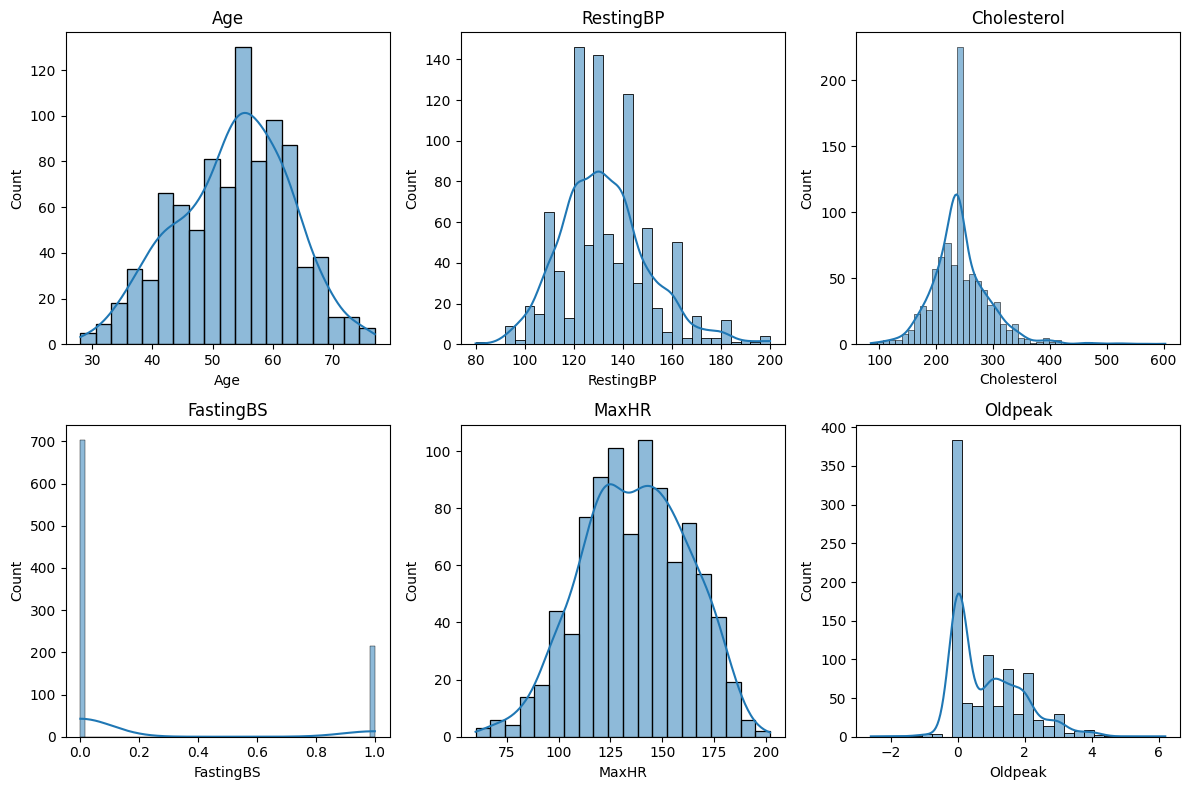

In [17]:
# num_cols = [...]: Define una lista con los nombres de las columnas numéricas que se desean visualizar.
num_cols = ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak']

# plt.figure(figsize=(12, 8)): Crea el lienzo principal de Matplotlib y establece el tamaño de la imagen (12x8 pulgadas).
plt.figure(figsize=(12, 8))

# for i, col in enumerate(num_cols, 1): Inicia un bucle que recorre la lista de columnas, asignando un índice (i) a cada una.
for i, col in enumerate(num_cols, 1):
    
    # plt.subplot(2, 3, i): Organiza la figura en una cuadrícula de 2 filas y 3 columnas, seleccionando la posición "i".
    plt.subplot(2, 3, i)
    
    # sns.histplot(..., kde=True): Dibuja el histograma y superpone una línea de densidad (KDE) para observar la distribución.
    sns.histplot(data[col], kde=True)
    
    # plt.title(col): Asigna el nombre de la variable médica como título individual para cada uno de los subgráficos.
    plt.title(col)

# plt.tight_layout(): Ajusta automáticamente el espacio entre subgráficos para evitar el solapamiento de etiquetas.
plt.tight_layout()

# plt.show(): Renderiza y despliega la figura completa con todos los histogramas en la interfaz del usuario.
plt.show()


Detección de Valores Atípicos mediante Diagramas de Caja para el Análisis de la Integridad Clínica:
Este procedimiento constituye una técnica fundamental del Análisis Exploratorio de Datos (EDA) para identificar registros extremos (outliers) que podrían distorsionar el entrenamiento del modelo. Al emplear el método sns.boxplot() de la librería Seaborn, se visualiza el rango intercuartílico, la mediana y la dispersión de las variables numéricas. Esta inspección permite determinar si factores como el colesterol o la presión arterial presentan valores biológicamente inusuales que requieran un tratamiento especial antes de la optimización con XGBoost.

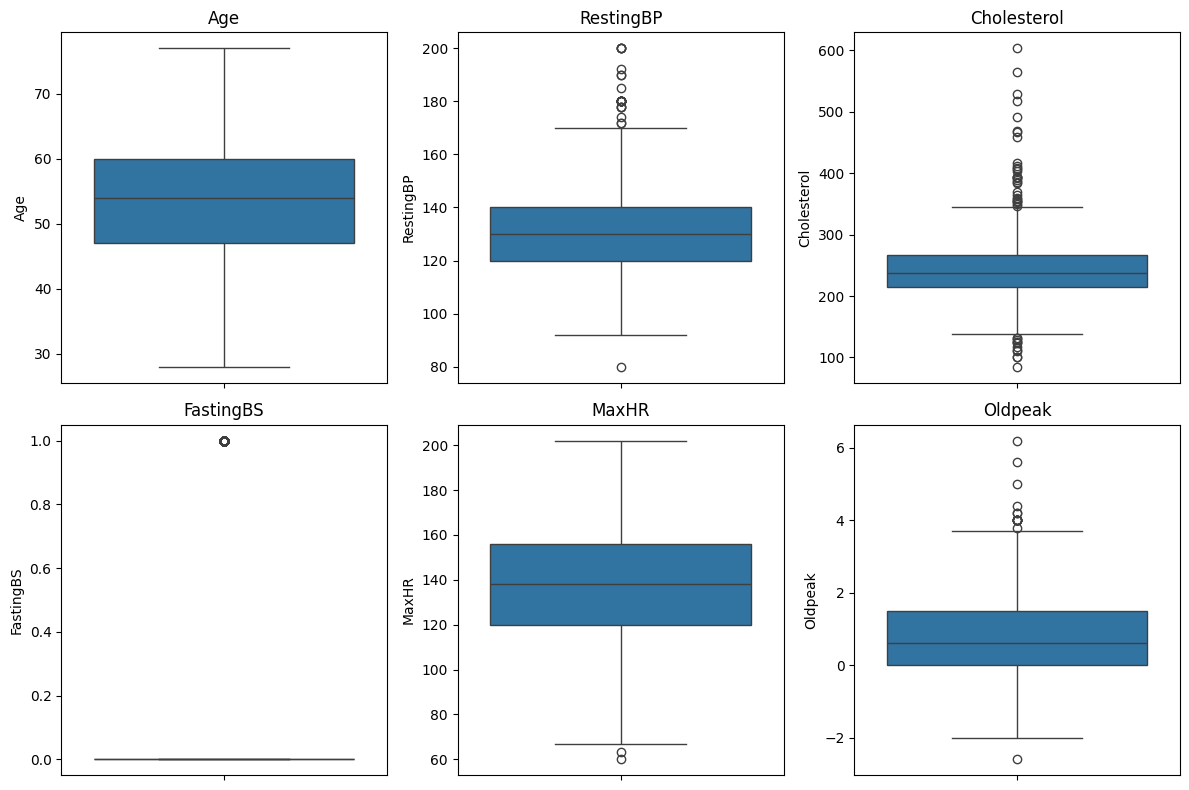

In [18]:
# plt.figure(figsize=(12, 8)): Prepara el área de dibujo de Matplotlib con un tamaño de 12x8 pulgadas para garantizar la legibilidad de los gráficos.
plt.figure(figsize=(12, 8))

# for i, col in enumerate(num_cols, 1): Inicia un bucle que recorre la lista de variables numéricas asignando a cada una una posición específica en la cuadrícula.
for i, col in enumerate(num_cols, 1):
    
    # plt.subplot(2, 3, i): Divide el lienzo principal en 6 secciones (2 filas y 3 columnas) y selecciona el espacio "i" para el gráfico actual.
    plt.subplot(2, 3, i)
    
    # sns.boxplot(y=data[col]): Genera un diagrama de caja vertical; los puntos situados fuera de los "bigotes" representan los valores atípicos (outliers).
    sns.boxplot(y=data[col])
    
    # plt.title(col): Asigna el nombre de la variable clínica en la parte superior de cada subgráfico para facilitar su identificación.
    plt.title(col)

# plt.tight_layout(): Ejecuta el ajuste automático del diseño para prevenir el solapamiento de los ejes y los títulos de las variables.
plt.tight_layout()

# plt.show(): Despliega la figura completa con la comparativa de todos los boxplots generados en la interfaz del usuario.
plt.show()


Visualización del Balance de la Variable Objetivo mediante un Gráfico de Frecuencias:
Este procedimiento estadístico traduce visualmente la proporción de pacientes sanos (0) frente a pacientes con enfermedad cardíaca (1). Al emplear el método sns.countplot() de la librería Seaborn, se genera una comparativa directa del volumen de datos en cada categoría. Esta inspección es fundamental para identificar un posible desbalance de clases, factor que podría comprometer la capacidad del modelo de XGBoost para detectar correctamente la clase minoritaria si no se aplican técnicas de compensación como SMOTE.

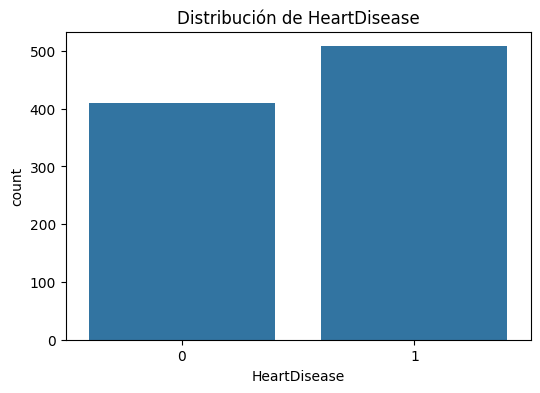

In [19]:
# plt.figure(figsize=(6,4)): Establece las dimensiones del lienzo de Matplotlib (6x4 pulgadas) para obtener una visualización compacta y clara.
plt.figure(figsize=(6,4))

# sns.countplot(x='HeartDisease', data=data): Genera un gráfico de barras que contabiliza automáticamente la frecuencia de cada categoría en la variable 'HeartDisease'.
# El eje 'x' representa las clases del diagnóstico y el eje 'y' la magnitud de la muestra de pacientes en cada grupo.
sns.countplot(x='HeartDisease', data=data)

# plt.title("Distribución de HeartDisease"): Incorpora un título descriptivo en la sección superior para contextualizar la interpretación del análisis clínico.
plt.title("Distribución de HeartDisease")

# plt.show(): Ejecuta el renderizado y despliega el gráfico de barras final en la interfaz del usuario.
plt.show()


Codificación Multiclase mediante One-Hot Encoding: Transformación de Categorías Nominales en Variables Binarias:
Este procedimiento técnico es esencial para tratar variables que no poseen un orden jerárquico (como el tipo de dolor de pecho, los resultados del electrocardiograma o la forma de la pendiente ST). Al aplicar el método pd.get_dummies() de la librería Pandas, se descomponen las columnas de texto en múltiples columnas nuevas de ceros y unos. Esta técnica evita que el modelo de XGBoost asuma erróneamente un orden de importancia entre las categorías, garantizando una interpretación matemática correcta durante el entrenamiento en Scikit-Learn.

In [20]:
# pd.get_dummies: Función de Pandas que aplica "One-Hot Encoding", creando nuevas columnas binarias (0 o 1) para cada categoría única.
# data: Representa el DataFrame original que contiene todas las variables clínicas del estudio.
# columns=['ChestPainType', 'RestingECG', 'ST_Slope']: Especifica la lista de columnas con múltiples categorías que se desean transformar.
# data = ... : Sobrescribe el DataFrame original con la nueva versión que integra las columnas expandidas en lugar de las originales de texto.


data = pd.get_dummies(data, columns=['ChestPainType', 'RestingECG', 'ST_Slope'])


Diccionario Técnico de Datos y Significado Clínico de las Variables Post-Procesamiento:
Este cuadro detallado describe la semántica de cada variable presente en el conjunto de datos tras la fase de ingeniería de características. Incluye tanto los indicadores biomédicos originales como las nuevas columnas binarias generadas mediante One-Hot Encoding. Esta referencia es fundamental para interpretar los resultados de la matriz de correlación y la importancia de variables del modelo de XGBoost con precisión médica.

| Variable | Significado |
|---|---|
| `Age` | Edad del paciente en años |
| `Sex` | Sexo del paciente (0: Mujer, 1: Hombre) |
| `RestingBP` | Presión arterial (BP: Blood Pressure) en reposo, medida en mm Hg |
| `Cholesterol` | Nivel de colesterol sérico en sangre, medido en mm/dl |
| `FastingBS` | Azúcar en sangre (BS: Blood Sugar) en ayunas (1: superior a 120 mg/dl, 0: normal) |
| `MaxHR` | Frecuencia cardíaca máxima (HR: Heart Rate) alcanzada durante el ejercicio |
| `ExerciseAngina` | Angina (dolor en el pecho) inducida por ejercicio (0: No, 1: Sí) |
| `Oldpeak` | Depresión del segmento ST del electrocardiograma inducida por ejercicio respecto al reposo |
| `HeartDisease` | Variable objetivo: presencia de enfermedad cardíaca (0: Normal, 1: Enfermo) |
| `ChestPainType_ASY` | Tipo de dolor torácico: ASY (Asymptomatic) — sin síntomas de dolor, el más peligroso |
| `ChestPainType_ATA` | Tipo de dolor torácico: ATA (Atypical Angina) — angina con síntomas atípicos |
| `ChestPainType_NAP` | Tipo de dolor torácico: NAP (Non-Anginal Pain) — dolor no relacionado con angina |
| `ChestPainType_TA` | Tipo de dolor torácico: TA (Typical Angina) — angina clásica con síntomas típicos |
| `ST_Slope_Down` | Pendiente del segmento ST (electrocardiograma) durante ejercicio: descendente, asociada a isquemia |
| `ST_Slope_Flat` | Pendiente del segmento ST durante ejercicio: plana, asociada a mayor riesgo cardíaco |
| `ST_Slope_Up` | Pendiente del segmento ST durante ejercicio: ascendente, considerada normal |
| `RestingECG_LVH` | ECG (Electrocardiograma) en reposo: LVH (Left Ventricular Hypertrophy) — hipertrofia del ventrículo izquierdo |
| `RestingECG_Normal` | ECG (Electrocardiograma) en reposo: resultado normal, sin anomalías detectadas |
| `RestingECG_ST` | ECG (Electrocardiograma) en reposo: anomalía en la onda ST-T, posible señal de enfermedad |

Visualización de Relaciones Lineales mediante un Mapa de Calor de la Matriz de Correlación:
Este procedimiento estadístico permite identificar el grado de asociación entre todas las variables del conjunto de datos. Al emplear el método data.corr() de Pandas y la visualización de Seaborn, se genera una matriz que revela qué factores clínicos (como la edad o el tipo de pendiente ST) tienen una relación más fuerte con la presencia de enfermedad cardíaca. Esta inspección es fundamental para la selección de características y para comprender los patrones que el modelo de XGBoost priorizará durante el entrenamiento en Scikit-Learn.

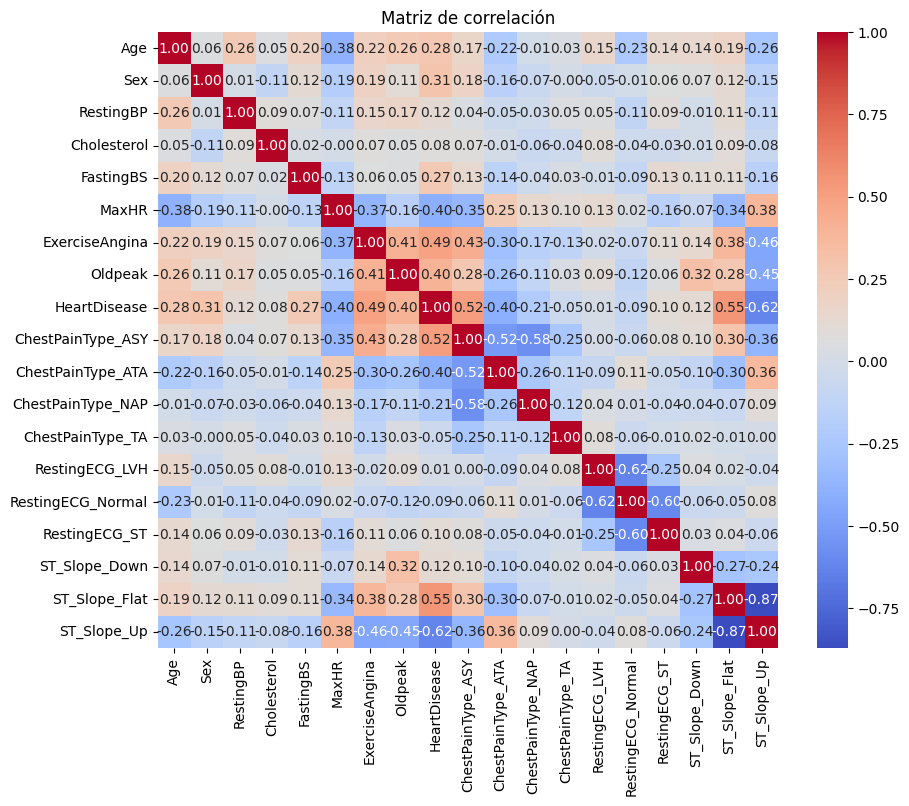

In [21]:
# plt.figure(figsize=(10, 8)): Establece las dimensiones del lienzo de Matplotlib (10x8 pulgadas) para garantizar que los coeficientes numéricos sean legibles.
plt.figure(figsize=(10, 8))

# corr = data.corr(): Calcula el coeficiente de correlación de Pearson para todos los pares de variables numéricas del DataFrame.
corr = data.corr()

# sns.heatmap(...): Genera la representación térmica de la matriz utilizando los siguientes parámetros técnicos:
#   - annot=True: Inserta el valor numérico de la correlación dentro de cada celda para un análisis preciso.
#   - fmt='.2f': Redondea los coeficientes a dos decimales para mejorar la claridad visual.
#   - cmap='coolwarm': Aplica una escala divergente (azul para correlación negativa, rojo para positiva) que facilita la detección de patrones.
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')

# plt.title("Matriz de correlación"): Define el título superior del gráfico para contextualizar el análisis de interdependencia de las variables.
plt.title("Matriz de correlación")

# plt.show(): Ejecuta el renderizado y despliega el mapa de calor final en la interfaz del usuario.
plt.show()


Análisis Comparativo de la Distribución de Edad según la Presencia de Enfermedad Cardíaca:
Este procedimiento de análisis bivariado permite examinar la relación entre una variable numérica (Edad) y la variable objetivo categórica (Enfermedad). Al emplear el método sns.boxplot() de la librería Seaborn, se visualiza cómo varían la mediana, los cuartiles y los valores atípicos de la edad entre pacientes sanos (0) y enfermos (1). Esta inspección es fundamental para confirmar la hipótesis de que la edad es un factor de riesgo determinante, patrón que el modelo de XGBoost utilizará para realizar clasificaciones precisas en Scikit-Learn.

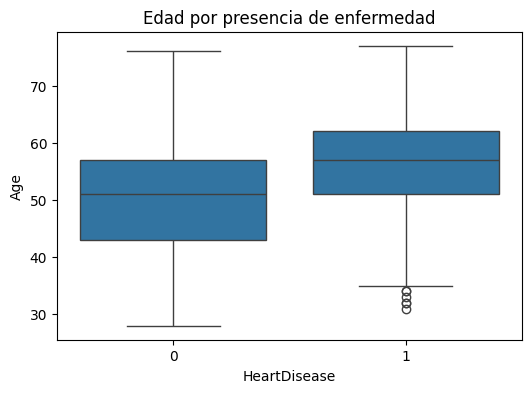

In [22]:
# plt.figure(figsize=(6,4)): Establece un tamaño de lienzo de 6x4 pulgadas de Matplotlib, ideal para un gráfico comparativo directo y legible.
plt.figure(figsize=(6,4))

# sns.boxplot(x='HeartDisease', y='Age', data=data): Genera un diagrama de caja que segmenta la variable 'Age' (eje Y) según las categorías de 'HeartDisease' (eje X).
# Esta visualización permite comparar la distribución, medianas y valores atípicos de la edad entre pacientes sanos (0) y enfermos (1).
sns.boxplot(x='HeartDisease', y='Age', data=data)

# plt.title("Edad por presencia de enfermedad"): Define el título descriptivo superior para identificar el propósito clínico de la comparativa.
plt.title("Edad por presencia de enfermedad")

# plt.show(): Ejecuta el renderizado y despliega el gráfico de caja final en la interfaz del usuario.
plt.show()


Comparativo de la Distribución de Colesterol según la Presencia de Enfermedad Cardíaca:
Este procedimiento de análisis bivariado permite examinar la relación entre una variable numérica crítica (Colesterol) y la variable objetivo categórica (Enfermedad). Al emplear el método sns.boxplot() de la librería Seaborn, se visualiza cómo varían la mediana, los cuartiles y los valores atípicos del colesterol entre pacientes sanos (0) y enfermos (1). Esta inspección es fundamental tras la fase de imputación por la mediana, permitiendo validar si los niveles de lípidos en sangre constituyen un factor diferencial que el modelo de XGBoost deba priorizar en Scikit-Learn.

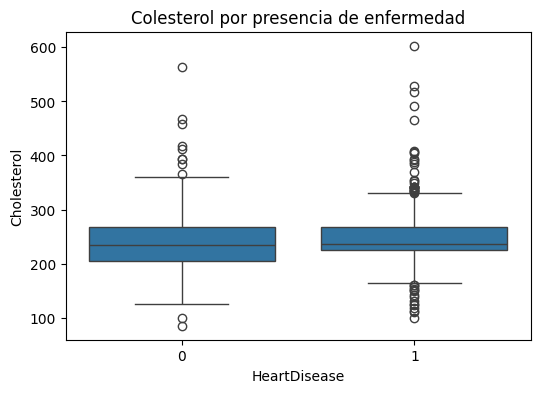

In [23]:
# plt.figure(figsize=(6,4)): Establece las dimensiones del lienzo de Matplotlib en 6 pulgadas de ancho por 4 de alto para garantizar una visualización clara y profesional.
plt.figure(figsize=(6,4))

# sns.boxplot(x='HeartDisease', y='Cholesterol', data=data): Genera un diagrama de caja que compara la distribución del 'Colesterol' (eje Y) entre los grupos con y sin 'HeartDisease' (eje X).
# Este gráfico permite observar las diferencias en las medianas, la dispersión de los datos y detectar valores atípicos (outliers) específicos en cada grupo de pacientes.
sns.boxplot(x='HeartDisease', y='Cholesterol', data=data)

# plt.title("Colesterol por presencia de enfermedad"): Incorpora un título descriptivo en la parte superior del gráfico para identificar formalmente la comparación realizada.
plt.title("Colesterol por presencia de enfermedad")

# plt.show(): Ejecuta el renderizado y despliega el gráfico de caja final en la interfaz del usuario.
plt.show()


Comparativa de frecuencia cardíaca máxima según la presencia de enfermedad.Análisis Comparativo de la Frecuencia Cardíaca Máxima según la Presencia de Enfermedad Cardíaca:
Este procedimiento de análisis bivariado permite examinar la relación entre una variable numérica de desempeño físico (Frecuencia Cardíaca Máxima) y la variable objetivo categórica (Enfermedad). Al emplear el método sns.boxplot() de la librería Seaborn, se visualiza cómo varían la mediana, los cuartiles y los valores atípicos de la variable MaxHR entre pacientes sanos (0) y enfermos (1). Esta inspección es fundamental para validar la capacidad de este indicador como predictor de riesgo, patrón que el modelo de XGBoost priorizará durante el entrenamiento en Scikit-Learn.

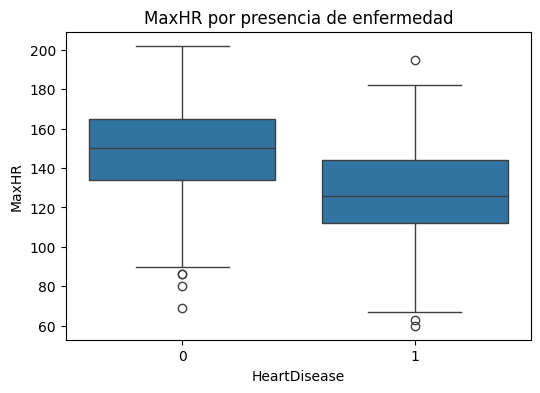

In [24]:
# plt.figure(figsize=(6,4)): Establece las dimensiones del lienzo de Matplotlib en 6 pulgadas de ancho por 4 de alto para garantizar una visualización clara y profesional.
plt.figure(figsize=(6,4))

# sns.boxplot(x='HeartDisease', y='MaxHR', data=data): Genera un diagrama de caja que compara la distribución de la frecuencia cardíaca máxima ('MaxHR', eje Y) entre los grupos con y sin 'HeartDisease' (eje X).
# Este gráfico permite observar si los pacientes enfermos tienden a alcanzar frecuencias cardíacas más bajas o altas durante el ejercicio en comparación con los sanos.
sns.boxplot(x='HeartDisease', y='MaxHR', data=data)

# plt.title("MaxHR por presencia de enfermedad"): Incorpora un título descriptivo en la parte superior del gráfico para identificar formalmente la comparación realizada.
plt.title("MaxHR por presencia de enfermedad")

# plt.show(): Ejecuta el renderizado y despliega el gráfico de caja final en la interfaz del usuario.
plt.show()


Análisis de la Incidencia de Tipos de Dolor Torácico en la Enfermedad Cardíaca: Relación entre Síntomas Asintomáticos, Anginas y Dolores No Anginales:
Este procedimiento estadístico y visual permite evaluar la relación entre las categorías de dolor torácico (derivadas del One-Hot Encoding) y el diagnóstico de enfermedad cardíaca. Al emplear el método groupby().sum() de la librería Pandas, se cuantifica la frecuencia de cada síntoma en pacientes sanos (0) y enfermos (1). Esta comparativa es fundamental para identificar "señales de alerta" médicas, como el dolor asintomático (ASY), factor que el modelo de XGBoost priorizará durante el entrenamiento en Scikit-Learn.

(Asintomático, angina atípica, no anginal, angina típica / ASY - ATA - NAP - TA ).

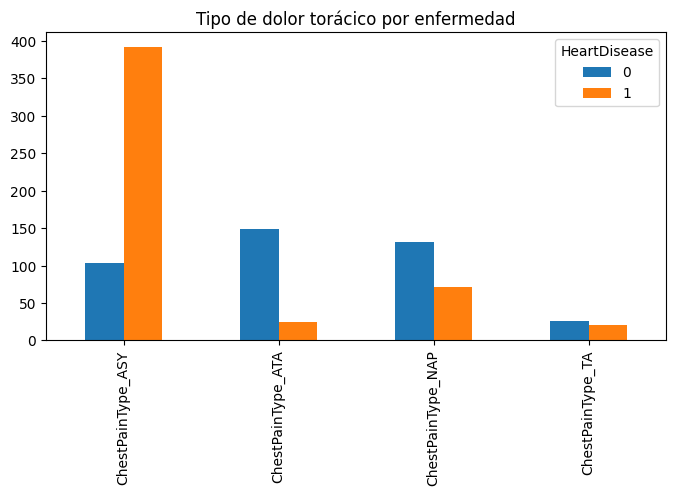

In [25]:
# chest_cols = [...]: Crea una lista con los nombres de las columnas binarias que representan los 4 tipos de dolor torácico.
# ChestPainType_ASY: ASY (Asymptomatic). Indica que el paciente no presenta dolor físico evidente, síntoma crítico en infartos silenciosos.
# ChestPainType_ATA: ATA (Atypical Angina). Dolor de pecho que no cumple con todos los criterios de una angina típica.
# ChestPainType_NAP: NAP (Non-Anginal Pain). Dolor en el pecho que no tiene origen cardíaco (ej. digestivo o muscular).
# ChestPainType_TA: TA (Typical Angina). El dolor clásico de opresión provocado por esfuerzo físico o estrés.
chest_cols = ['ChestPainType_ASY', 'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA']

# data[chest_cols + ['HeartDisease']]: Selecciona las columnas de dolor y la variable objetivo para el análisis específico.
# .groupby('HeartDisease').sum(): Agrupa los registros por diagnóstico y suma los valores binarios de cada tipo de dolor.
# .T: Transpone la tabla para situar los tipos de dolor en el eje horizontal (X) y facilitar la lectura comparativa.
# .plot(kind='bar', figsize=(8,4)): Genera un gráfico de barras de Pandas con dimensiones de 8x4 pulgadas.
data[chest_cols + ['HeartDisease']].groupby('HeartDisease').sum().T.plot(kind='bar', figsize=(8,4))

# plt.title("Tipo de dolor torácico por enfermedad"): Asigna un título descriptivo superior a la visualización.
plt.title("Tipo de dolor torácico por enfermedad")

# plt.show(): Renderiza y despliega el gráfico de barras comparativo final en la interfaz del usuario.
plt.show()


Relación entre la Pendiente del Segmento ST (Ascendente, Plana, Descendente) y la Enfermedad Cardíaca:
Este procedimiento estadístico y visual permite evaluar la correlación entre los diferentes tipos de pendiente observados en el segmento ST del electrocardiograma y el diagnóstico final. Al emplear el método groupby().sum() de la librería Pandas, se cuantifica la frecuencia de cada comportamiento eléctrico en pacientes sanos (0) y enfermos (1). Esta comparativa es fundamental para identificar indicadores críticos de isquemia, como la pendiente plana (Flat) o descendente (Down), factores que el modelo de XGBoost priorizará para realizar clasificaciones precisas.

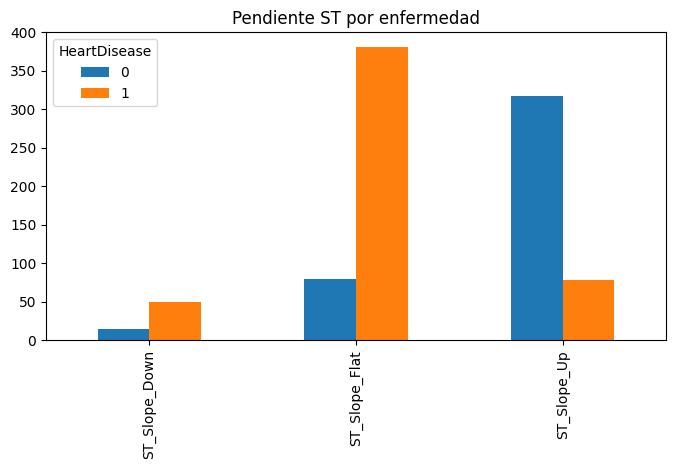

In [26]:
# st_cols: Define las 3 categorías de la pendiente ST resultantes del proceso de One-Hot Encoding: Down (Descendente), Flat (Plana) y Up (Ascendente).
st_cols = ['ST_Slope_Down', 'ST_Slope_Flat', 'ST_Slope_Up']

# data[st_cols + ['HeartDisease']]: Selecciona las columnas de la pendiente ST y la variable objetivo (HeartDisease) del DataFrame original.
# .groupby('HeartDisease').sum(): Agrupa a los pacientes por estado de salud (0) o enfermedad (1) y suma las ocurrencias de cada tipo de pendiente detectada.
# .T: Transpone la matriz de datos para situar los tipos de pendiente (Down, Flat, Up) en el eje horizontal (X) y facilitar la lectura del gráfico.
# .plot(kind='bar', figsize=(8,4)): Genera un gráfico de barras comparativo de Pandas con dimensiones de 8x4 pulgadas.
data[st_cols + ['HeartDisease']].groupby('HeartDisease').sum().T.plot(kind='bar', figsize=(8,4))

# plt.title("Pendiente ST por enfermedad"): Asigna el título descriptivo superior para identificar formalmente el propósito de la visualización clínica.
plt.title("Pendiente ST por enfermedad")

# plt.show(): Renderiza y despliega el gráfico de barras comparativo final en la interfaz del usuario.
plt.show()


Matriz de Dispersión Multivariada con Segmentación por Diagnóstico Cardíaco:
Este procedimiento constituye la visualización más completa del Análisis Exploratorio de Datos (EDA). Al emplear el método sns.pairplot() de la librería Seaborn, se genera una cuadrícula que cruza todas las variables numéricas entre sí. Esta matriz permite identificar de forma simultánea las correlaciones, las distribuciones individuales y la capacidad de separación que tienen los datos clínicos (como Age, Cholesterol y MaxHR) para distinguir entre pacientes sanos y enfermos antes de iniciar el modelado con XGBoost.


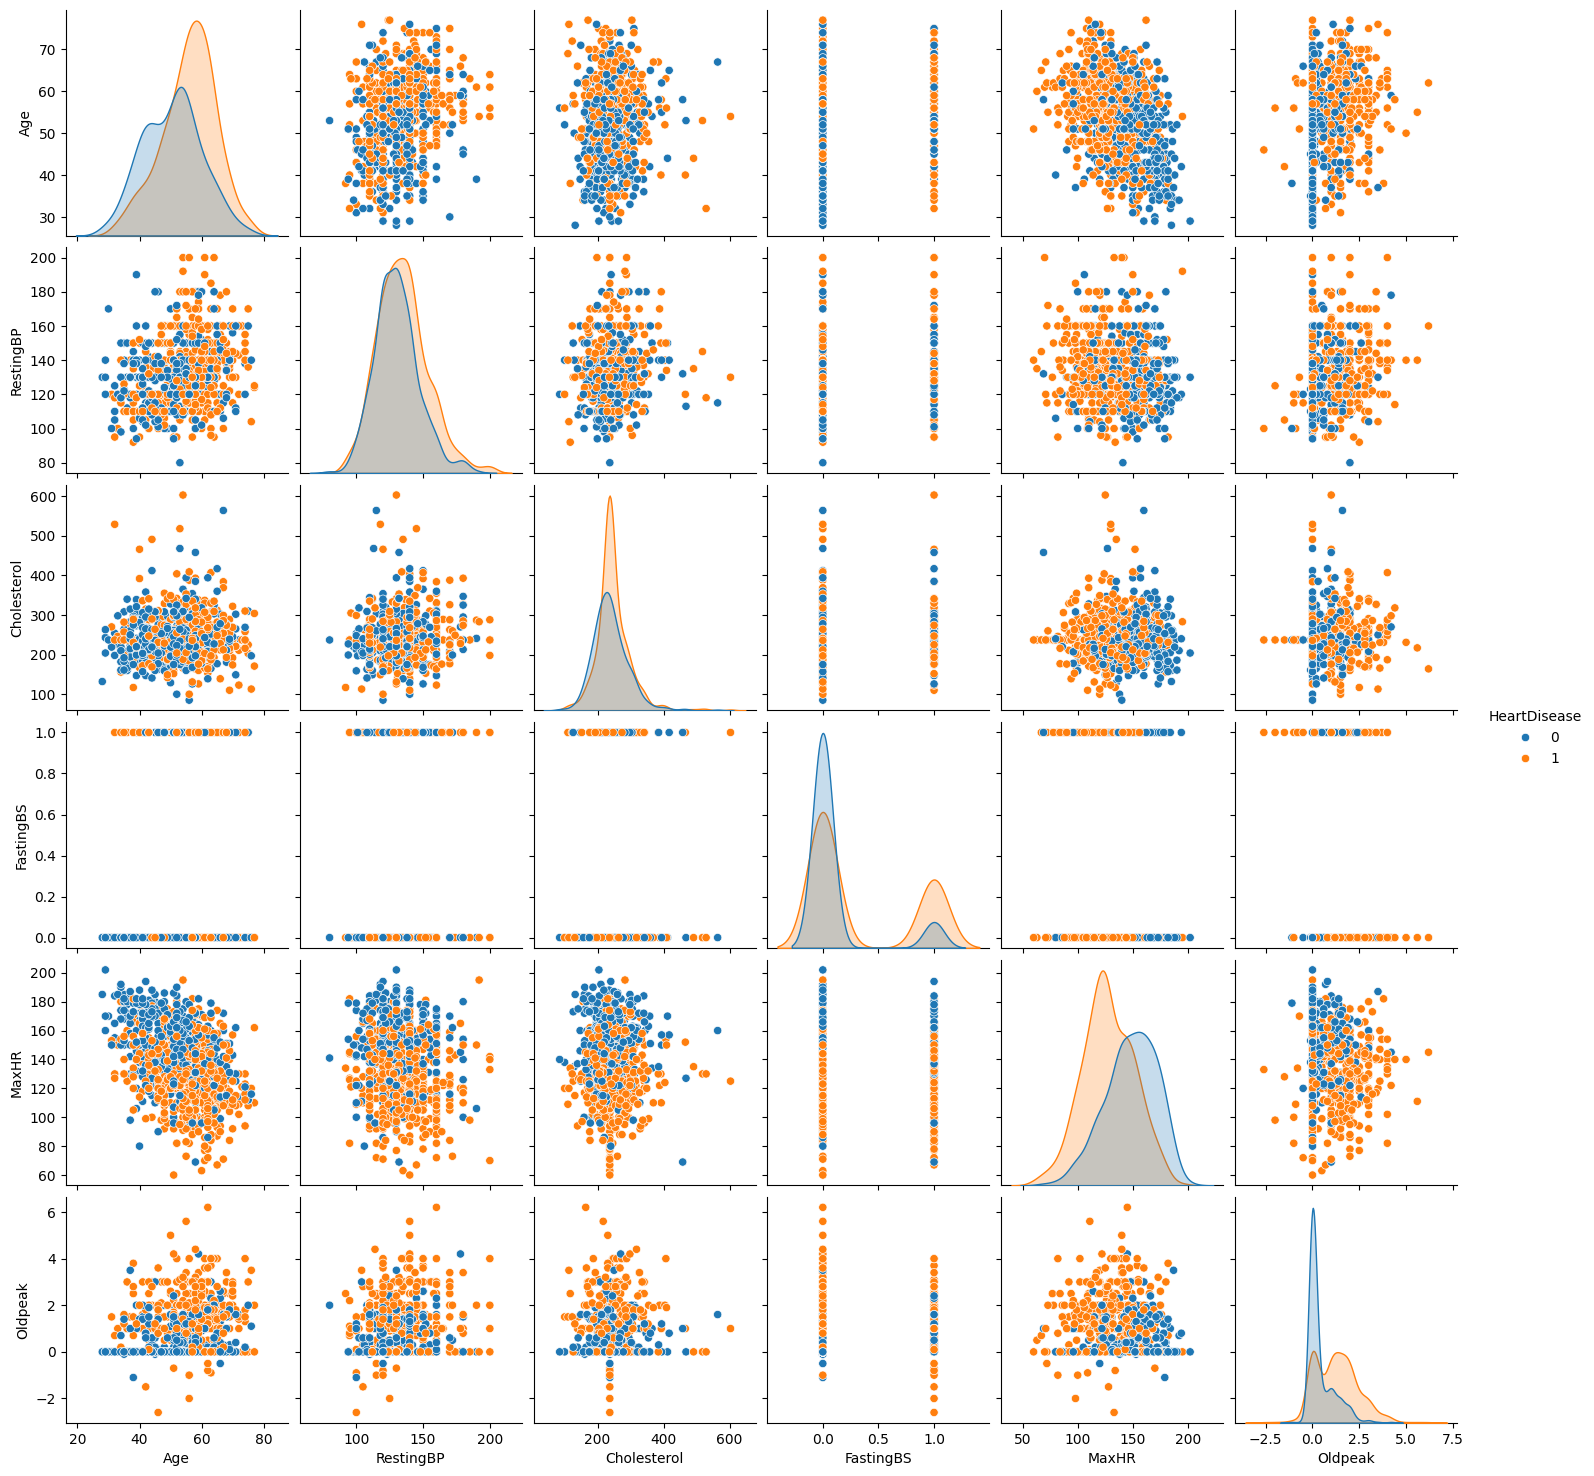

In [27]:
# sns.pairplot(...): Función de la librería Seaborn que crea una cuadrícula exhaustiva de gráficos para analizar relaciones entre variables.
# data[num_cols + ['HeartDisease']]: Selecciona exclusivamente las columnas numéricas de interés y la variable objetivo para el estudio.
# hue='HeartDisease': Segmenta y colorea los puntos del gráfico según el diagnóstico (0: Sano, 1: Enfermo), facilitando la detección de patrones visuales.
# Diagonales: Muestran la distribución suavizada (KDE) de cada variable de forma individual para comparar ambos grupos de pacientes.
# Fuera de la diagonal: Generan diagramas de dispersión (Scatter plots) que revelan cómo interactúan dos variables clínicas simultáneamente.
sns.pairplot(data[num_cols + ['HeartDisease']], hue='HeartDisease')

# plt.show(): Ejecuta el renderizado y despliega la matriz completa de gráficos en la interfaz del usuario.
plt.show()


## Entrenamiento mediante XGBoost

Definición de Variables Predictoras (Características) y Variable Objetivo (Etiqueta):
Este procedimiento técnico marca la transición entre la fase de preprocesamiento y el inicio del modelado con XGBoost. Consiste en la fragmentación del conjunto de datos en dos entidades distintas: una matriz de características (X) que contiene los indicadores clínicos y un vector objetivo (y) que almacena los diagnósticos de enfermedad cardíaca. Al emplear el método drop() de Pandas, se garantiza que el modelo aprenda a predecir el resultado basándose únicamente en los predictores, sin tener acceso previo a la respuesta correcta durante el entrenamiento en Scikit-Learn.


In [28]:
# X = data.drop('HeartDisease', axis=1): Crea una nueva estructura de datos 'X' que integra todas las columnas del dataset excepto 'HeartDisease'.
# axis=1: Parámetro que especifica la eliminación de una columna completa (eje vertical) para definir las variables independientes o "Features".
X = data.drop('HeartDisease', axis=1)

# y = data['HeartDisease']: Genera una serie 'y' que contiene exclusivamente la columna que se desea predecir mediante el algoritmo.
# Representa el "Target" o variable dependiente, clasificada en dos categorías (0: Sano, 1: Enfermo).
y = data['HeartDisease']


División del conjunto de datos en entrenamiento (Train) y prueba (Test).Fragmentación del Conjunto de Datos en Subconjuntos de Entrenamiento y Prueba para la Validación del Modelo:
Este procedimiento constituye una de las fases más críticas en la construcción de sistemas de Machine Learning. Al emplear la función train_test_split de la librería Scikit-Learn, se dividen las características (X) y el objetivo (y) en dos grupos independientes. El objetivo primordial es reservar una porción de los datos reales para evaluar la capacidad de generalización del algoritmo de XGBoost ante pacientes nuevos, garantizando que el rendimiento medido mediante el Recall y el F1-Score no sea producto de una simple memorización de los datos.

In [29]:
# X_train, X_test, y_train, y_test = ...: Ejecuta una "asignación múltiple" que genera cuatro estructuras de datos independientes:
#   - X_train: Matriz de características clínicas destinada a la fase de aprendizaje del modelo (80% del total).
#   - X_test: Matriz de características reservada exclusivamente para la evaluación final de rendimiento (20% del total).
#   - y_train: Vector de diagnósticos reales (etiquetas) correspondientes al conjunto de entrenamiento.
#   - y_test: Vector de diagnósticos reales reservados para contrastar las predicciones finales del sistema.

# X, y: Representan las variables de características y el objetivo clínico definidos en la etapa anterior de preprocesamiento.

# test_size=0.2: Define la proporción de la división, asignando el 20% de los datos al conjunto de prueba y el 80% restante al entrenamiento.

# random_state=42: Establece una semilla de aleatoriedad fija que garantiza la reproducibilidad de la división. 
# Esto permite que los experimentos posteriores y la optimización con Optuna se realicen siempre sobre la misma partición de pacientes.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


Entrenamiento del Modelo de Clasificación Base mediante el Algoritmo XGBoost:
Este procedimiento marca el inicio de la fase de modelado predictivo. Al emplear el estimador XGBClassifier de la librería XGBoost, se construye un modelo basado en el aprendizaje por refuerzo de árboles de decisión (Gradient Boosting). Durante este proceso, el algoritmo analiza las características clínicas presentes en el conjunto de entrenamiento para establecer las reglas matemáticas que permiten predecir el diagnóstico de enfermedad cardíaca, sentando la base para la posterior optimización con Optuna.

In [30]:
# Crea una instancia del clasificador configurando el 'random_state=42' para garantizar que el proceso de entrenamiento sea reproducible y no varíe en cada ejecución.
model = XGBClassifier(random_state=42)

# Ejecuta el proceso de entrenamiento (fit), donde el modelo analiza exhaustivamente los datos de 'X_train' para identificar los patrones que expliquen las etiquetas de 'y_train'.
# Durante esta fase, el algoritmo construye de forma secuencial una serie de árboles de decisión que minimizan el error de predicción en el diagnóstico.
model.fit(X_train, y_train)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

Evaluación del Rendimiento Predictivo mediante el Reporte de Clasificación:
Este procedimiento constituye la fase de validación cuantitativa del modelo base. Al emplear el método predict() de la librería XGBoost, el sistema genera diagnósticos para el conjunto de prueba (X_test) basándose en los patrones clínicos identificados durante el entrenamiento. Posteriormente, mediante la función classification_report() de Scikit-Learn, se contrastan estas predicciones con las etiquetas reales (y_test) para obtener métricas críticas como la precisión, el Recall y el F1-Score.

In [31]:
# Genera las predicciones finales: el modelo procesa los datos clínicos de los pacientes en 'X_test' para determinar la presencia de enfermedad cardíaca basándose en el aprendizaje previo.
y_pred = model.predict(X_test)

# Ejecuta el reporte de métricas detallado que compara los diagnósticos reales (y_test) con las predicciones del sistema (y_pred).
# Proporciona una visión exhaustiva del rendimiento por clase (Sano vs. Enfermo), facilitando la detección de sesgos en el diagnóstico.
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.81      0.87      0.84        77
           1       0.90      0.85      0.88       107

    accuracy                           0.86       184
   macro avg       0.85      0.86      0.86       184
weighted avg       0.86      0.86      0.86       184



Visualización de Aciertos y Errores Diagnósticos mediante la Matriz de Confusión:
Este procedimiento constituye la fase de validación cualitativa del modelo. Al emplear el método confusion_matrix() de la librería Scikit-Learn, se desglosan las predicciones del modelo de XGBoost en cuatro cuadrantes críticos: verdaderos positivos, verdaderos negativos, falsos positivos y falsos negativos. Esta inspección visual, representada mediante ConfusionMatrixDisplay(), es fundamental para identificar específicamente cuántos pacientes enfermos fueron omitidos por el sistema, permitiendo ajustar la estrategia de Recall antes de la optimización con Optuna.

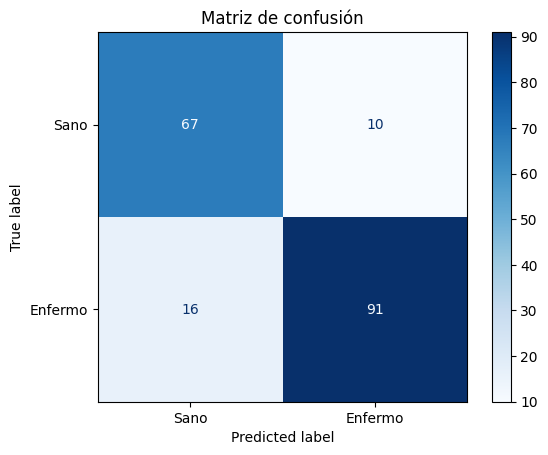

In [32]:
# Calcula la matriz de confusión contrastando los diagnósticos reales (y_test) con las predicciones generadas por el modelo (y_pred).
# Esta operación permite cuantificar los aciertos y los errores específicos cometidos durante la fase de evaluación.
cm = confusion_matrix(y_test, y_pred)

# Genera la representación visual de la matriz utilizando la utilidad de Scikit-Learn.
# Se asignan las etiquetas 'Sano' y 'Enfermo' a los ejes para facilitar la interpretación clínica y se aplica una escala de colores (cmap='Blues').
ConfusionMatrixDisplay(cm, display_labels=['Sano', 'Enfermo']).plot(cmap='Blues')

# Incorpora el título descriptivo superior al gráfico para contextualizar el análisis de errores en el diagnóstico cardíaco.
plt.title("Matriz de confusión")

# Ejecuta el renderizado y despliega la matriz de confusión final en la interfaz del usuario.
plt.show()


Evaluación de la Capacidad de Discriminación Diagnóstica mediante la Curva ROC y el Cálculo del AUC:
Este procedimiento constituye el estándar de validación en la medicina predictiva para medir la eficacia de un sistema de diagnóstico. Al emplear el método RocCurveDisplay.from_estimator() de la librería Scikit-Learn, se representa gráficamente la relación entre la sensibilidad (Recall) y la tasa de falsos positivos para el modelo de XGBoost. El resultado principal es el AUC (Area Under the Curve), una métrica global que cuantifica la probabilidad de que el algoritmo distinga correctamente entre un paciente con enfermedad cardíaca y uno sano.

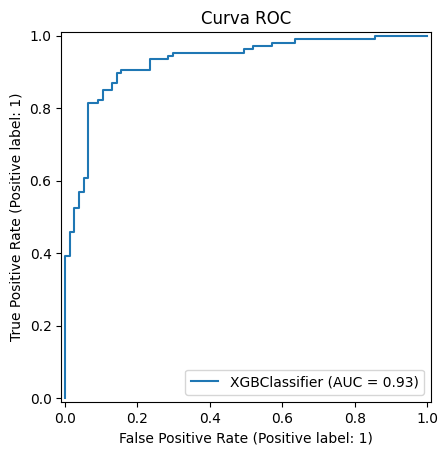

In [33]:
# Utiliza el estimador (modelo XGBoost entrenado) y los datos de prueba (X_test, y_test) para calcular la Tasa de Verdaderos Positivos frente a la Tasa de Falsos Positivos.
# Este método de Scikit-Learn genera automáticamente los puntos de la curva probando diferentes umbrales de decisión.
RocCurveDisplay.from_estimator(model, X_test, y_test)

# Añade un título descriptivo superior al gráfico para identificar formalmente el análisis de sensibilidad y especificidad del modelo.
plt.title("Curva ROC")

# Ejecuta el renderizado y despliega la gráfica final, la cual incorpora de forma automática el valor numérico del AUC (Área Bajo la Curva).
plt.show()


Identificación de las Características Predictoras mediante el Análisis de Importancia de Variables en XGBoost:
Este procedimiento constituye la fase de interpretabilidad del modelo, permitiendo conocer qué factores médicos (como el colesterol, la edad o el tipo de dolor torácico) tienen un mayor impacto en la toma de decisiones del algoritmo. Al emplear el método plot_importance() de la librería XGBoost, se genera una jerarquía visual basada en la frecuencia con la que cada variable fue utilizada para dividir los nodos de los árboles de decisión. Esta inspección es fundamental para validar la coherencia clínica del sistema y para priorizar los indicadores de riesgo en el diagnóstico cardíaco.

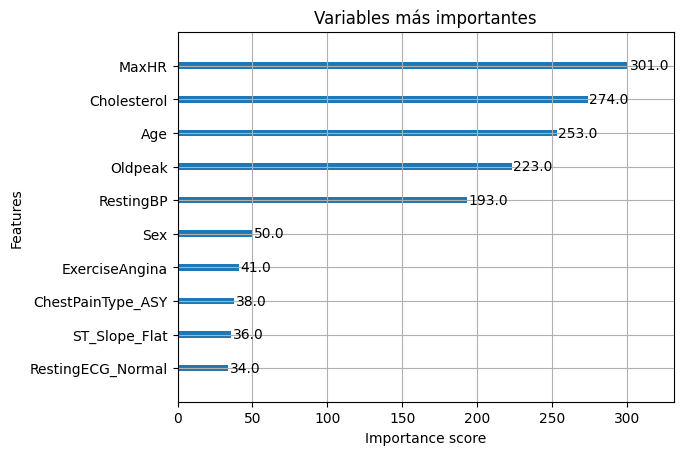

In [34]:
# Genera un gráfico de barras horizontal donde el modelo clasifica las variables que más aportaron al proceso de decisión.
# El método plot_importance de XGBoost cuantifica la relevancia de cada característica según su ganancia o frecuencia de uso.
# max_num_features=10: Limita el gráfico a las 10 variables con mayor peso para facilitar la lectura y el análisis médico.
plot_importance(model, max_num_features=10)

# Asigna un título descriptivo superior a la visualización para identificar formalmente el análisis de relevancia de las variables clínicas.
plt.title("Variables más importantes")

# Ejecuta el renderizado y despliega el gráfico de barras horizontal final en la interfaz del usuario.
plt.show()


Diagnóstico del Rendimiento mediante Curvas de Aprendizaje para la Detección de Sobreajuste o Subajuste:
Este procedimiento constituye la fase de auditoría del aprendizaje del modelo. Al emplear la función learning_curve() de la librería Scikit-Learn, se evalúa cómo evoluciona la precisión del algoritmo de XGBoost a medida que aumenta el volumen de datos de entrenamiento. Esta visualización es fundamental para determinar si el sistema padece de overfitting (memorización de ruidos) o underfitting (falta de complejidad), permitiendo ajustar la estrategia de regularización antes de iniciar la optimización con Optuna.


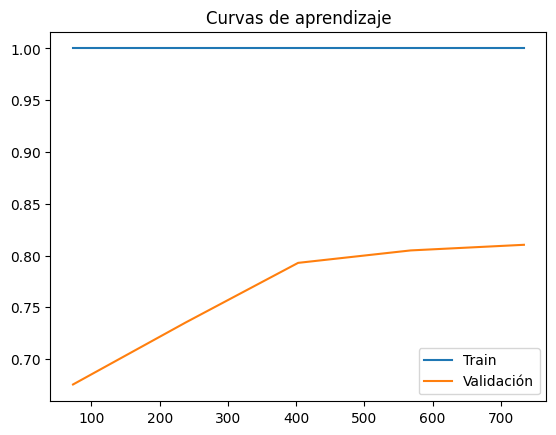

In [35]:
# #Curvas de aprendizaje: Comentario que identifica el análisis del rendimiento del modelo conforme aumenta la cantidad de datos.

# learning_curve(...): Función de Scikit-Learn que entrena el modelo de forma iterativa con diferentes tamaños de muestra (train_sizes).
# model, X, y: Utiliza el estimador XGBoost configurado y el conjunto de datos completo (características y objetivo).
# cv=5: Aplica una Validación Cruzada de 5 pliegues para garantizar que los resultados de precisión sean estadísticamente robustos.
# scoring='accuracy': Establece la exactitud (porcentaje de aciertos globales) como métrica para medir el éxito del aprendizaje.
train_sizes, train_scores, val_scores = learning_curve(model, X, y, cv=5, scoring='accuracy')

# plt.plot(train_sizes, train_scores.mean(axis=1), label='Train'): Dibuja la línea de precisión obtenida sobre los datos de entrenamiento a medida que crece el dataset.
plt.plot(train_sizes, train_scores.mean(axis=1), label='Train')

# plt.plot(train_sizes, val_scores.mean(axis=1), label='Validación'): Dibuja la línea de precisión lograda sobre los datos de validación que el modelo no conoce.
plt.plot(train_sizes, val_scores.mean(axis=1), label='Validación')

# plt.title("Curvas de aprendizaje"): Incorpora un título descriptivo superior a la gráfica para facilitar su identificación técnica.
plt.title("Curvas de aprendizaje")

# plt.legend(): Despliega el cuadro de etiquetas para diferenciar visualmente el comportamiento de la línea de 'Train' frente a la de 'Validación'.
plt.legend()

# plt.show(): Ejecuta el renderizado y despliega la gráfica de aprendizaje final en la interfaz del usuario.
plt.show()


### Utilización de OPTUNA para optimizar el modelo.

Configuración de la Función Objetivo para la Optimización de Hiperparámetros mediante Optuna:
Este procedimiento técnico establece la lógica de búsqueda inteligente para sintonizar el modelo de XGBoost. Al definir la función objective(), se instruye a la librería Optuna sobre qué parámetros explorar y bajo qué límites. El objetivo primordial es automatizar el hallazgo de la combinación óptima de configuraciones (como la profundidad de los árboles o la tasa de aprendizaje) que maximice el rendimiento del diagnóstico cardíaco, evaluando cada intento mediante Validación Cruzada para asegurar la robustez de los resultados.

In [36]:
# def objective(trial): Define la función que Optuna ejecutará repetidamente; el objeto 'trial' sugiere nuevos valores en cada intento.
def objective(trial):
    
    # params = { ... }: Diccionario que define el "espacio de búsqueda" de los hiperparámetros del modelo.
    params = {
        # trial.suggest_int: Sugiere un número entero de árboles entre 100 y 500 para el bosque de decisión.
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        
        # trial.suggest_int: Sugiere la profundidad máxima de cada árbol (entre 3 y 10 niveles) para controlar la complejidad del modelo.
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        
        # trial.suggest_float: Sugiere la tasa de aprendizaje (velocidad de ajuste) en un rango continuo de 0.01 a 0.3.
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        
        # trial.suggest_float: Define la proporción de muestras (filas) que utilizará cada árbol para mitigar el sobreajuste.
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        
        # trial.suggest_float: Define la proporción de características (columnas) seleccionadas para la construcción de cada árbol.
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        
        # trial.suggest_float (reg_alpha/reg_lambda): Sugiere valores de regularización L1 y L2 para penalizar la complejidad excesiva del modelo.
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 10),
        'reg_lambda': trial.suggest_float('reg_lambda', 0, 10),
        
        # Mantiene la semilla de aleatoriedad fija para garantizar que los experimentos sean técnicamente comparables.
        'random_state': 42
    }
    
    # model = XGBClassifier(**params): Instancia el clasificador de XGBoost desempaquetando los parámetros sugeridos por la prueba actual.
    model = XGBClassifier(**params)
    
    # score = cross_val_score(...).mean(): Evalúa el modelo empleando Validación Cruzada de 5 pliegues y promedia el valor de la métrica 'f1'.
    score = cross_val_score(model, X_train, y_train, cv=5, scoring='f1').mean()
    
    # return score: Devuelve el puntaje F1 resultante para que Optuna determine la calidad de la combinación evaluada.
    return score


Ejecución de la Optimización Inteligente de Hiperparámetros con Estrategia de Parada Temprana (Early Stopping):
Este procedimiento constituye la fase de ejecución del experimento de sintonización del modelo. Al emplear el método create_study() de la librería Optuna, se inicia un proceso de búsqueda bayesiana para encontrar la configuración óptima de XGBoost. La inclusión de un mecanismo de Early Stopping mediante callbacks permite que el sistema detecte cuándo el rendimiento ha alcanzado una meseta, deteniendo las iteraciones innecesarias y optimizando el tiempo de cómputo sin comprometer la calidad del diagnóstico final.

In [37]:
# optuna.create_study: Instancia el objeto del experimento que gestionará la búsqueda de parámetros.
# direction='maximize': Instruye a Optuna para que busque la combinación que alcance el valor más alto posible del F1-Score.
study = optuna.create_study(direction='maximize')

# study.optimize: Inicia el proceso de búsqueda iterativa de hiperparámetros en el modelo.
# n_trials=200: Define un límite máximo de 200 combinaciones distintas para ser evaluadas por el algoritmo.
# callbacks=[...]: Implementa una función de "parada temprana" para mejorar la eficiencia del proceso.
# lambda study, trial: Si tras 20 intentos consecutivos no se supera el mejor puntaje registrado, la optimización se detiene automáticamente para optimizar los recursos.
study.optimize(
    objective,
    n_trials=200,
    callbacks=[lambda study, trial: study.stop() if study.best_trial.number + 20 < trial.number else None]
)


[I 2026-03-05 10:35:29,026] A new study created in memory with name: no-name-94862a75-3ba4-4900-95f3-217a85860ecc
[I 2026-03-05 10:35:29,417] Trial 0 finished with value: 0.8721763597654938 and parameters: {'n_estimators': 294, 'max_depth': 9, 'learning_rate': 0.28269453656044025, 'subsample': 0.9481202608687922, 'colsample_bytree': 0.8744126146281862, 'reg_alpha': 7.25322837233133, 'reg_lambda': 3.907244739262219}. Best is trial 0 with value: 0.8721763597654938.
[I 2026-03-05 10:35:29,631] Trial 1 finished with value: 0.8743665047456141 and parameters: {'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.2592661930603042, 'subsample': 0.6122631946916304, 'colsample_bytree': 0.6090886057706801, 'reg_alpha': 6.0831852496489915, 'reg_lambda': 6.1486238607836885}. Best is trial 1 with value: 0.8743665047456141.
[I 2026-03-05 10:35:30,374] Trial 2 finished with value: 0.8730634259251646 and parameters: {'n_estimators': 472, 'max_depth': 5, 'learning_rate': 0.08624783559955705, 'subsamp

Entrenamiento y Evaluación de Desempeño del Modelo Final Optimizado con Hiperparámetros Definidos por Optuna:
Este procedimiento representa la culminación de la fase de modelado, donde se construye el clasificador definitivo utilizando la configuración óptima identificada durante el proceso de búsqueda bayesiana. Al emplear el método XGBClassifier de la librería XGBoost con los parámetros desempaquetados de Optuna, se garantiza que el sistema de diagnóstico cardíaco opere con su máxima eficiencia. La evaluación final sobre el conjunto de prueba (X_test) mediante el classification_report() de Scikit-Learn permite certificar el rendimiento del modelo en términos de precisión y Recall antes de su implementación clínica.

In [38]:
# Crea una nueva instancia de XGBClassifier desempaquetando (**) los mejores hiperparámetros encontrados de forma automática por Optuna.
# random_state=42: Asegura que la construcción de los árboles de decisión en el modelo final sea reproducible y consistente.
best_model = XGBClassifier(**study.best_params, random_state=42)

# Entrena el modelo optimizado utilizando el conjunto de datos de entrenamiento completo (X_train, y_train).
# En esta etapa, el algoritmo ajusta sus pesos finales para maximizar la detección de patrones médicos.
best_model.fit(X_train, y_train)

# Genera las predicciones finales utilizando los datos de prueba (X_test) que el modelo nunca ha analizado previamente.
# Este paso es fundamental para medir la capacidad de generalización del sistema ante nuevos pacientes.
y_pred_best = best_model.predict(X_test)

# Imprime el reporte de desempeño final comparando las etiquetas diagnósticas reales con las predicciones del modelo.
# target_names=['Sano', 'Enfermo']: Sustituye las etiquetas numéricas (0 y 1) por términos clínicos para facilitar la lectura del reporte.
print(classification_report(y_test, y_pred_best, target_names=['Sano', 'Enfermo']))


              precision    recall  f1-score   support

        Sano       0.85      0.88      0.87        77
     Enfermo       0.91      0.89      0.90       107

    accuracy                           0.89       184
   macro avg       0.88      0.89      0.88       184
weighted avg       0.89      0.89      0.89       184



Diagnóstico de Generalización mediante el Análisis de Brecha entre Entrenamiento y Prueba (Overfitting):
Este procedimiento constituye la prueba de integridad definitiva para el modelo de XGBoost. Al emplear el método score() de Scikit-Learn, se compara el rendimiento obtenido con los datos conocidos (X_train) frente a los datos reservados (X_test). El objetivo primordial es cuantificar el overfitting (sobreajuste): una diferencia mínima entre ambos puntajes garantiza que el sistema no ha memorizado ruidos estadísticos, sino que ha desarrollado una capacidad real para diagnosticar la enfermedad cardíaca en pacientes nuevos.

In [39]:
# Calcula la precisión (accuracy) del modelo utilizando los datos clínicos con los que fue entrenado (X_train, y_train).
# Este valor indica el límite superior de rendimiento que el algoritmo de XGBoost alcanzó durante el aprendizaje.
train_score = best_model.score(X_train, y_train)

# Calcula la precisión del modelo utilizando los datos de prueba (X_test, y_test) que el sistema nunca ha analizado previamente.
# Representa la capacidad de generalización del modelo en un escenario de diagnóstico médico real.
test_score = best_model.score(X_test, y_test)

# Muestra el resultado obtenido en el conjunto de entrenamiento con una precisión de cuatro decimales.
print(f"Train: {train_score:.4f}")

# Muestra el resultado del conjunto de prueba para evaluar la eficacia predictiva ante nuevos casos clínicos.
print(f"Test:  {test_score:.4f}")

# Calcula y muestra el valor absoluto de la brecha entre ambos puntajes para cuantificar técnicamente el nivel de sobreajuste.
# Una diferencia reducida es el indicador principal de un modelo robusto y confiable.
print(f"Diferencia: {abs(train_score - test_score):.4f}")


Train: 0.9755
Test:  0.8859
Diferencia: 0.0896


Refinamiento de Regularización Manual para la Reducción de Sobreajuste en el Modelo Maestro:
Este procedimiento constituye una fase de ajuste fino (fine-tuning) aplicada tras la optimización automatizada. Aunque Optuna identifica los mejores parámetros, en ocasiones es necesario imponer restricciones adicionales de regularización para garantizar que el modelo de XGBoost sea lo más simple y robusto posible. Al limitar la profundidad de los árboles y aumentar los requisitos para nuevas divisiones de nodos, se busca reducir la brecha entre el rendimiento de entrenamiento y el de prueba, asegurando que el diagnóstico cardíaco sea fiable ante datos médicos totalmente nuevos.

In [40]:
# best_params = study.best_params: Recupera del objeto de estudio los hiperparámetros óptimos identificados por Optuna.
best_params = study.best_params

# best_params['max_depth'] = ...: Limita la profundidad máxima de los árboles a un nivel de 5 para prevenir que el modelo memorice ruidos específicos.
best_params['max_depth'] = min(best_params.get('max_depth', 6), 5)

# best_params['min_child_weight'] = 5: Define un peso mínimo de 5 muestras para permitir la creación de nuevos nodos, frenando el sobreajuste.
best_params['min_child_weight'] = 5

# best_params['gamma'] = 1: Establece un umbral de reducción de pérdida mínimo para realizar particiones en los árboles de decisión.
best_params['gamma'] = 1

# Crea la instancia definitiva de XGBClassifier integrando los parámetros de Optuna con las restricciones manuales de regularización.
best_model = XGBClassifier(**best_params, random_state=42)

# Ejecuta el reentrenamiento del modelo utilizando el conjunto de datos de entrenamiento (X_train, y_train) bajo estas reglas más estrictas.
best_model.fit(X_train, y_train)

# Calcula nuevamente el puntaje de precisión en el conjunto de entrenamiento (Train) tras la aplicación de la regularización.
train_score = best_model.score(X_train, y_train)

# Evalúa la precisión en el conjunto de prueba (Test) para certificar la mejora en la capacidad de generalización del sistema.
test_score = best_model.score(X_test, y_test)

# Muestra los puntajes actualizados y la diferencia absoluta para validar la reducción del desfase entre aprendizaje y validación.
print(f"Train: {train_score:.4f}")
print(f"Test:  {test_score:.4f}")
print(f"Diferencia: {abs(train_score - test_score):.4f}")


Train: 0.8978
Test:  0.8696
Diferencia: 0.0283


Evaluación visual del modelo final optimizado mediante hiperparámetros.

Visualización de Aciertos y Errores Diagnósticos mediante la Matriz de Confusión del Modelo Optimizado:
Este procedimiento constituye la validación cualitativa final del sistema tras el proceso de sintonización de hiperparámetros. Al emplear el método confusion_matrix() de la librería Scikit-Learn, se desglosan las predicciones del modelo de XGBoost en los cuatro cuadrantes fundamentales del diagnóstico clínico. La representación gráfica mediante ConfusionMatrixDisplay() permite confirmar visualmente si la optimización con Optuna logró reducir los falsos negativos y mejorar la precisión general en la detección de la enfermedad cardíaca.

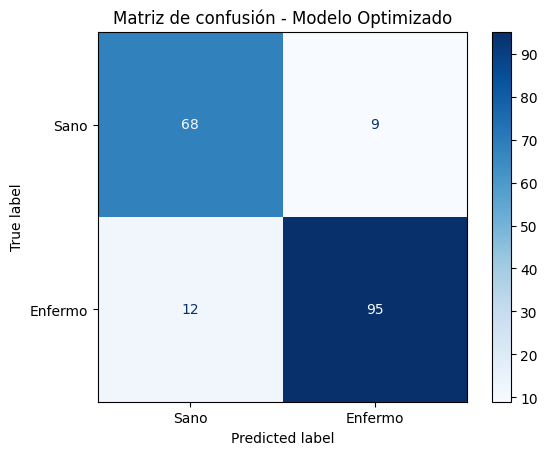

In [41]:
# cm = confusion_matrix(...): Calcula la matriz final contrastando los diagnósticos reales (y_test) con las predicciones del modelo optimizado (y_pred_best).
# Esta función organiza estadísticamente los resultados en: Verdaderos Negativos, Falsos Positivos, Falsos Negativos y Verdaderos Positivos.
cm = confusion_matrix(y_test, y_pred_best)

# ConfusionMatrixDisplay(...).plot(cmap='Blues'): Genera la interfaz visual de la matriz para facilitar su interpretación técnica.
# display_labels=['Sano', 'Enfermo']: Sustituye las etiquetas numéricas (0 y 1) por términos clínicos para una lectura médica directa.
# cmap='Blues': Aplica una escala cromática azul donde la intensidad del color indica una mayor concentración de casos en cada cuadrante.
ConfusionMatrixDisplay(cm, display_labels=['Sano', 'Enfermo']).plot(cmap='Blues')

# plt.title(...): Incorpora el título descriptivo superior para diferenciar este análisis del rendimiento obtenido por el modelo base inicial.
plt.title("Matriz de confusión - Modelo Optimizado")

# plt.show(): Ejecuta el renderizado y despliega la matriz de confusión optimizada en la interfaz del usuario.
plt.show()


Evaluación de la Capacidad de Discriminación Diagnóstica mediante la Curva ROC del Modelo Optimizado:
Este procedimiento constituye el estándar de validación final para medir la eficacia del sistema tras el proceso de sintonización de hiperparámetros. Al emplear el método RocCurveDisplay.from_estimator() de la librería Scikit-Learn, se representa gráficamente la relación entre la sensibilidad (Recall) y la tasa de falsos positivos para el modelo de XGBoost. El resultado principal es el AUC (Area Under the Curve), una métrica global que cuantifica la probabilidad de que el algoritmo optimizado distinga correctamente entre un paciente con enfermedad cardíaca y uno sano en cualquier umbral de decisión.

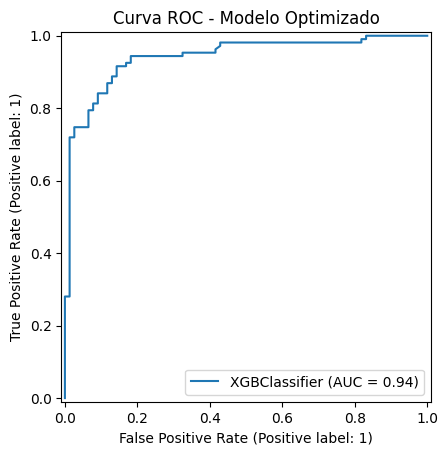

In [42]:
# RocCurveDisplay.from_estimator: Utiliza el modelo definitivo (best_model) y los datos de prueba (X_test, y_test) para generar la curva.
# Esta función de Scikit-Learn calcula automáticamente la relación entre la sensibilidad (verdaderos positivos) y la especificidad (falsos positivos).
RocCurveDisplay.from_estimator(best_model, X_test, y_test)

# plt.title(...): Añade un título descriptivo superior que identifica formalmente este gráfico como el rendimiento definitivo tras la optimización de parámetros.
plt.title("Curva ROC - Modelo Optimizado")

# plt.show(): Ejecuta el renderizado y despliega la gráfica de la curva ROC final en la interfaz del usuario.
plt.show()


Identificación de las Características Predictoras Finales mediante el Análisis de Importancia de Variables del Modelo Optimizado (Feature importance):
Este procedimiento constituye la fase de interpretabilidad definitiva del sistema. Al emplear el método plot_importance() de la librería XGBoost, se establece la jerarquía final de los factores médicos (como el colesterol, la frecuencia cardíaca o la pendiente ST) que más influyen en el diagnóstico. Esta visualización, aplicada sobre el modelo tras la optimización con Optuna y los ajustes de regularización, permite validar que las decisiones del algoritmo se basan en indicadores clínicos sólidos y coherentes con la literatura médica actual.

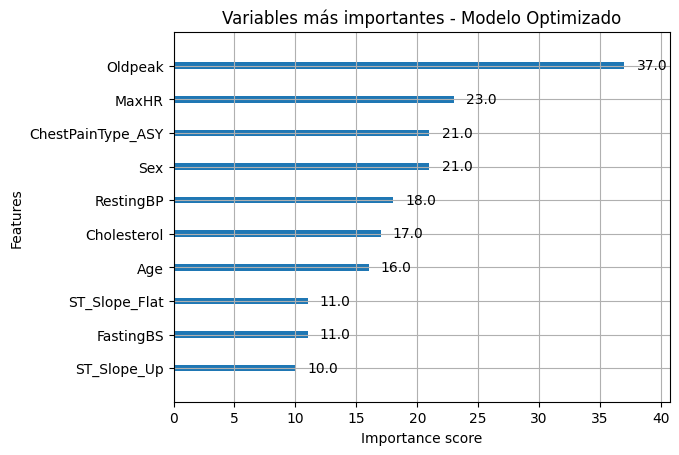

In [43]:
# plot_importance: Función de la librería [XGBoost](https://xgboost.readthedocs.io) que clasifica las variables según su aporte estadístico a la predicción final.
# best_model: Utiliza el modelo maestro que ya ha sido sometido a la optimización de [Optuna](https://optuna.org) y a la regularización manual de parámetros.
# max_num_features=10: Filtra la visualización para mostrar únicamente las 10 variables con mayor impacto, garantizando un análisis claro y enfocado.
plot_importance(best_model, max_num_features=10)

# plt.title(...): Asigna el título superior definitivo que confirma la validez de este análisis sobre la versión final y optimizada del modelo.
plt.title("Variables más importantes - Modelo Optimizado")

# plt.show(): Ejecuta el renderizado y despliega el gráfico de barras horizontal final en la interfaz del usuario.
plt.show()


Diagnóstico de Robustez y Capacidad de Generalización mediante Curvas de Aprendizaje del Modelo Optimizado:
Este procedimiento constituye la auditoría final del comportamiento del sistema tras la sintonización de hiperparámetros. Al emplear la función learning_curve() de la librería Scikit-Learn, se evalúa la convergencia entre el rendimiento de entrenamiento y el de validación a medida que aumenta el volumen de datos. Esta visualización permite certificar que las técnicas de regularización aplicadas al modelo de XGBoost han mitigado con éxito el overfitting, garantizando que el diagnóstico de enfermedad cardíaca sea estable y aplicable a nuevos pacientes en un entorno clínico real.

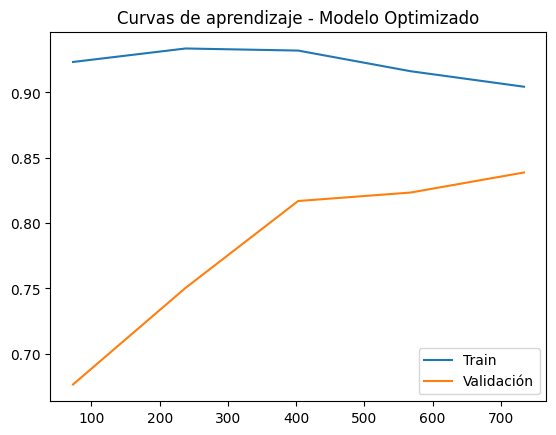

In [44]:
# learning_curve: Función de Scikit-Learn que entrena el modelo de forma iterativa con muestras de tamaño creciente.
# best_model, X, y: Utiliza el modelo maestro optimizado y el dataset completo para evaluar la evolución del aprendizaje técnico.
# cv=5: Aplica una Validación Cruzada de 5 pliegues para asegurar que los resultados de precisión no dependan de una partición de datos específica.
# scoring='accuracy': Establece la exactitud (porcentaje de aciertos) como métrica para medir el éxito del aprendizaje en ambas curvas.
train_sizes, train_scores, val_scores = learning_curve(best_model, X, y, cv=5, scoring='accuracy')

# plt.plot(..., label='Train'): Dibuja la precisión obtenida en los datos de entrenamiento; un valor alto pero no unitario indica un aprendizaje saludable sin memorización.
plt.plot(train_sizes, train_scores.mean(axis=1), label='Train')

# plt.plot(..., label='Validación'): Dibuja la precisión lograda sobre datos desconocidos; el éxito se define por la proximidad de esta línea a la de entrenamiento.
plt.plot(train_sizes, val_scores.mean(axis=1), label='Validación')

# plt.title(...): Asigna un título descriptivo superior que identifica formalmente este análisis como el cierre del proceso de optimización del sistema.
plt.title("Curvas de aprendizaje - Modelo Optimizado")

# plt.legend(): Despliega la leyenda informativa para diferenciar visualmente el comportamiento de las curvas de 'Train' y 'Validación'.
plt.legend()

# plt.show(): Ejecuta el renderizado y despliega la gráfica de aprendizaje final en la interfaz del usuario.
plt.show()


Validación Cruzada Estratificada para la Evaluación de Estabilidad y Robustez del Modelo Optimizado:
Este procedimiento constituye la auditoría estadística definitiva del sistema. Al emplear la técnica de StratifiedKFold de la librería Scikit-Learn, se divide el conjunto de datos en cinco particiones que conservan la proporción original de pacientes sanos y enfermos. El modelo de XGBoost se entrena y valida de forma rotativa en cada una de estas secciones, permitiendo obtener un promedio del F1-Score y su desviación estándar. Esta validación es fundamental para certificar que el rendimiento del diagnóstico cardíaco es consistente en todo el dataset y no depende de una partición aleatoria favorable.

In [45]:
# Instancia el objeto de validación cruzada estratificada configurado con 5 divisiones (folds).
# shuffle=True: Ejecuta una mezcla aleatoria de los registros antes de la fragmentación para eliminar sesgos derivados del orden de recolección de los datos.
# random_state=42: Establece una semilla de aleatoriedad fija para garantizar que la mezcla y las particiones sean reproducibles en experimentos posteriores.
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# cross_val_score: Ejecuta el entrenamiento y la evaluación del modelo optimizado (best_model) en cinco iteraciones independientes.
# En cada ciclo, el sistema utiliza 4 particiones para el aprendizaje y reserva 1 para la validación, rotando hasta completar el conjunto de datos.
# scoring='f1': Define el F1-Score como la métrica de éxito para garantizar un equilibrio riguroso entre la precisión y la sensibilidad médica.
scores = cross_val_score(best_model, X, y, cv=skf, scoring='f1')

# Muestra el puntaje F1 obtenido en cada una de las 5 iteraciones para analizar la variabilidad del rendimiento del modelo.
print(f"F1 por fold: {scores}")

# Calcula y despliega el promedio aritmético de los 5 puntajes para establecer una métrica de desempeño global, objetiva y confiable.
print(f"F1 media: {scores.mean():.4f}")

# Calcula la desviación estándar de los resultados para cuantificar la dispersión; una cifra reducida confirma que el modelo es altamente estable.
print(f"Desviación estándar: {scores.std():.4f}")


F1 por fold: [0.92       0.89       0.85046729 0.91262136 0.86384977]
F1 media: 0.8874
Desviación estándar: 0.0269


Balanceo de Clases mediante SMOTE para la Optimización de la Sensibilidad Diagnóstica:
Este procedimiento técnico aborda el desequilibrio en el conjunto de entrenamiento para evitar que el modelo de XGBoost desarrolle un sesgo hacia la clase mayoritaria. Al emplear el algoritmo SMOTE (Synthetic Minority Over-sampling Technique), se generan ejemplos sintéticos de la clase minoritaria (pacientes enfermos) basados en la proximidad estadística de los datos reales. Esta ecualización de las categorías es fundamental para mejorar el Recall y asegurar que el sistema de Machine Learning aprenda con la misma rigurosidad a identificar tanto a pacientes sanos como a aquellos con riesgo cardíaco.

In [46]:
# # Intento de reducir el desequillibrio: Comentario técnico que indica el inicio de la fase de rebalanceo de datos.

# smote = SMOTE(random_state=42): Crea una instancia del algoritmo SMOTE de la librería imbalanced-learn.
# random_state=42: Establece una semilla de aleatoriedad fija para garantizar que la creación de datos sintéticos sea consistente y reproducible.
smote = SMOTE(random_state=42)

# smote.fit_resample(X_train, y_train): Ejecuta el sobremuestreo generando nuevos registros sintéticos para la clase con menos muestras.
# X_train_sm, y_train_sm: Representan los nuevos conjuntos de entrenamiento donde ambas clases (Sano/Enfermo) poseen ahora una representación equitativa.
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

# Muestra la distribución original de pacientes en el conjunto de entrenamiento para contrastar el estado inicial del desbalance.
print(f"Antes - Sano: {y_train.value_counts()[0]}, Enfermo: {y_train.value_counts()[1]}")

# Confirma que, tras la aplicación de SMOTE, ambas categorías cuentan con el mismo número de registros, eliminando el sesgo algorítmico.
print(f"Después - Sano: {y_train_sm.value_counts()[0]}, Enfermo: {y_train_sm.value_counts()[1]}")


Antes - Sano: 333, Enfermo: 401
Después - Sano: 401, Enfermo: 401


Entrenamiento y Evaluación del Modelo Maestro con Balanceo SMOTE e Hiperparámetros Optimizados:
Este procedimiento representa la construcción de la versión más robusta del sistema de diagnóstico. Al combinar los parámetros de regularización obtenidos mediante Optuna con el conjunto de datos equilibrado artificialmente por SMOTE, se elimina el sesgo hacia la clase mayoritaria. El entrenamiento del modelo de XGBoost sobre X_train_sm permite que el algoritmo asigne la misma importancia estadística a los pacientes sanos y enfermos, mejorando sustancialmente el Recall y garantizando un diagnóstico más equitativo y preciso ante casos reales.

In [47]:
# best_model_sm = XGBClassifier(...): Instancia el modelo utilizando la configuración de parámetros previos y la semilla de aleatoriedad 42.
# **best_params: Desempaqueta el diccionario de hiperparámetros optimizados y regularizados para asegurar un modelo equilibrado y robusto.
best_model_sm = XGBClassifier(**best_params, random_state=42)

# best_model_sm.fit(X_train_sm, y_train_sm): Ejecuta el entrenamiento utilizando el conjunto de datos balanceado donde ambas clases poseen la misma representación.
# Este proceso de ajuste permite que el algoritmo de XGBoost identifique patrones de riesgo sin verse influenciado por el desbalance original de la muestra.
best_model_sm.fit(X_train_sm, y_train_sm)

# y_pred_sm = best_model_sm.predict(X_test): Genera las predicciones finales sobre el conjunto de prueba (X_test), el cual conserva las proporciones clínicas reales.
# Este paso es fundamental para validar el rendimiento del sistema ante pacientes que nunca han sido analizados por el modelo.
y_pred_sm = best_model_sm.predict(X_test)

# print(classification_report(...)): Despliega el reporte exhaustivo de métricas comparando los diagnósticos reales con las predicciones del modelo balanceado.
# target_names=['Sano', 'Enfermo']: Sustituye las etiquetas numéricas por términos médicos para facilitar la interpretación de los resultados de precisión y sensibilidad.
print(classification_report(y_test, y_pred_sm, target_names=['Sano', 'Enfermo']))


              precision    recall  f1-score   support

        Sano       0.81      0.87      0.84        77
     Enfermo       0.90      0.85      0.88       107

    accuracy                           0.86       184
   macro avg       0.85      0.86      0.86       184
weighted avg       0.86      0.86      0.86       184



Optimización del Umbral de Decisión Clínico para la Maximización de la Sensibilidad Diagnóstica (Recall):
Este procedimiento constituye una fase avanzada de post-procesamiento orientada a la seguridad del paciente. Al emplear el método predict_proba() de la librería XGBoost, el sistema extrae la probabilidad continua de riesgo en lugar de una clasificación binaria rígida. Ajustar el umbral de decisión de 0.5 a 0.4 permite que el modelo sea más preventivo, clasificando a un paciente como "Enfermo" ante una probabilidad del 40% o superior. Esta calibración técnica es fundamental en el ámbito de la salud para elevar el Recall y minimizar la omisión de casos críticos de enfermedad cardíaca.

In [48]:
# predict_proba(X_test)[:, 1]: En lugar de realizar una predicción binaria (0 o 1), el modelo calcula la probabilidad estadística (de 0.0 a 1.0) de que el paciente pertenezca a la clase 'Enfermo'.
# [:, 1]: Filtra y selecciona exclusivamente la columna de probabilidad correspondiente a la presencia de enfermedad cardíaca (clase 1).
y_prob_sm = best_model_sm.predict_proba(X_test)[:, 1]

# (y_prob_sm >= 0.4): Ejecuta la re-clasificación modificando el umbral estándar de 0.5 a un nivel más sensible de 0.4. Si el riesgo detectado es del 40% o superior, el sistema activa la alerta de 'Enfermo'.
# .astype(int): Transforma los resultados lógicos (True/False) obtenidos de la comparación en valores numéricos enteros (1 y 0).
y_pred_threshold = (y_prob_sm >= 0.4).astype(int)

# classification_report(...): Genera el reporte de métricas exhaustivo para evaluar el rendimiento del sistema tras la aplicación del umbral preventivo.
# target_names=['Sano', 'Enfermo']: Asocia las etiquetas numéricas finales con términos clínicos para facilitar la interpretación del impacto en la detección cardíaca.
print(classification_report(y_test, y_pred_threshold, target_names=['Sano', 'Enfermo']))


              precision    recall  f1-score   support

        Sano       0.85      0.83      0.84        77
     Enfermo       0.88      0.90      0.89       107

    accuracy                           0.87       184
   macro avg       0.87      0.86      0.87       184
weighted avg       0.87      0.87      0.87       184



Simulación de Umbrales de Decisión para la Optimización del Recall y el F1-Score en el Diagnóstico Cardíaco:
Este procedimiento consiste en una evaluación iterativa de la sensibilidad del modelo de XGBoost. Dado que en cardiología un Falso Negativo (no detectar a un enfermo) puede tener consecuencias fatales, se simulan diferentes niveles de exigencia probabilística (de 0.5 a 0.2). Al reducir el umbral, el modelo se vuelve "más alarmista", lo cual es deseable para tamizajes iniciales. Este análisis permite identificar el Trade-off (intercambio) técnico: a medida que el Recall aumenta para capturar a más pacientes en riesgo, el F1-Score puede disminuir debido al incremento de falsas alarmas. La Decisión Basada en Datos permite elegir, por ejemplo, el umbral de 0.4 si logra una sensibilidad excelente manteniendo un equilibrio de precisión aceptable.

In [49]:
# for umbral in [0.5, 0.4, 0.3, 0.2]: Itera a través de diferentes niveles de exigencia de probabilidad (del 50% al 20%) para clasificar a alguien como 'Enfermo'.
for umbral in [0.5, 0.4, 0.3, 0.2]:
    
    # (y_prob_sm >= umbral): Compara la probabilidad devuelta por el modelo con el umbral actual del bucle.
    # .astype(int): Transforma los resultados Verdadero/Falso en 1 (Enfermo) y 0 (Sano).
    y_pred_t = (y_prob_sm >= umbral).astype(int)
    
    # Importa las funciones de [Scikit-Learn](https://scikit-learn.org) para calcular el Recall y el F1-Score en cada iteración.
    from sklearn.metrics import f1_score, recall_score
    
    # recall_score: Mide qué porcentaje de los enfermos reales (y_test) fueron capturados por las nuevas predicciones (y_pred_t).
    recall = recall_score(y_test, y_pred_t)
    
    # f1_score: Calcula el equilibrio entre la precisión (no dar falsas alarmas) y el recall (no dejar escapar enfermos).
    f1 = f1_score(y_test, y_pred_t)
    
    # print(...): Muestra los resultados comparativos para que el científico de datos elija el umbral más seguro clínicamente.
    print(f"Umbral {umbral} → Recall Enfermo: {recall:.4f} | F1: {f1:.4f}")


Umbral 0.5 → Recall Enfermo: 0.8505 | F1: 0.8750
Umbral 0.4 → Recall Enfermo: 0.8972 | F1: 0.8889
Umbral 0.3 → Recall Enfermo: 0.9252 | F1: 0.8959
Umbral 0.2 → Recall Enfermo: 0.9439 | F1: 0.8860


Implementación del Modelo Final con Umbral Clínico Optimizado (0.4)

Redefiniendo el objetivo de OPTUNA con recall.

Optimización Estratégica con Optuna para la Maximización del Recall en el Diagnóstico Cardíaco:
Este procedimiento realiza una sintonización avanzada de hiperparámetros mediante la librería Optuna, orientando la búsqueda de XGBoost hacia la máxima sensibilidad clínica (Recall). El proceso utiliza Validación Cruzada sobre datos balanceados con SMOTE e impone restricciones de regularización para asegurar que la capacidad de detección sea robusta y no producto del sobreajuste.

In [62]:
# def objective_recall(trial): Define la función que Optuna ejecutará repetidamente para encontrar la configuración con mayor Recall.
def objective_recall(trial):
    
    # params = { ... }: Configura el espacio de búsqueda de parámetros, limitando la profundidad (max_depth) a 5 para evitar el sobreajuste.
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500), # Cantidad de árboles de decisión.
        'max_depth': trial.suggest_int('max_depth', 3, 5),           # Profundidad máxima limitada para mayor generalización.
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3), # Velocidad de aprendizaje del modelo.
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),     # Fracción de muestras usadas por árbol.
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0), # Fracción de columnas usadas por árbol.
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 10),        # Regularización L1 para simplificar el modelo.
        'reg_lambda': trial.suggest_float('reg_lambda', 0, 10),      # Regularización L2 para evitar valores extremos.
        'min_child_weight': 5,                                       # Peso mínimo en nodos para frenar el ruido.
        'gamma': 1,                                                  # Umbral de pérdida para nuevas divisiones.
        'random_state': 42                                           # Semilla para resultados reproducibles.
    }
    
    # model = XGBClassifier(**params): Crea el modelo con los parámetros sugeridos en este intento (trial).
    model = XGBClassifier(**params)
    
    # score = cross_val_score(...): Evalúa el modelo usando Validación Cruzada sobre los datos balanceados (SMOTE), midiendo el 'recall'.
    # Usar 'recall' como métrica asegura que el modelo se esfuerce en identificar la mayor cantidad de casos positivos.
    score = cross_val_score(model, X_train_sm, y_train_sm, cv=5, scoring='recall').mean()
    
    # return score: Entrega el resultado a Optuna para que aprenda qué parámetros suben la sensibilidad.
    return score

# optuna.create_study: Inicia un nuevo experimento enfocado en maximizar el puntaje obtenido.
study_recall = optuna.create_study(direction='maximize')

# study_recall.optimize: Ejecuta hasta 200 intentos buscando el mejor Recall.
# El callback de 'Early Stopping' detiene la búsqueda si tras 20 intentos no hay una mejora real, ahorrando tiempo.
study_recall.optimize(
    objective_recall,
    n_trials=200,
    callbacks=[lambda study, trial: study.stop() if study.best_trial.number + 20 < trial.number else None]
)

# Imprime los parámetros ideales que maximizan la capacidad de detección de enfermedades del modelo.
print("Mejores hiperparámetros:", study_recall.best_params)
print("Número del mejor trial:", study_recall.best_trial.number)


[I 2026-03-05 11:06:52,857] A new study created in memory with name: no-name-e16fc9d3-f5b6-4a2e-93af-d9f39f0fafe6
[I 2026-03-05 11:06:53,174] Trial 0 finished with value: 0.897716049382716 and parameters: {'n_estimators': 174, 'max_depth': 4, 'learning_rate': 0.26259956162077164, 'subsample': 0.8057914691750269, 'colsample_bytree': 0.8856742296453941, 'reg_alpha': 2.7569139166324383, 'reg_lambda': 2.9723453599062433}. Best is trial 0 with value: 0.897716049382716.
[I 2026-03-05 11:06:53,646] Trial 1 finished with value: 0.8827469135802468 and parameters: {'n_estimators': 410, 'max_depth': 3, 'learning_rate': 0.17402997924591315, 'subsample': 0.7123780101179416, 'colsample_bytree': 0.9942575963906403, 'reg_alpha': 9.9310524732032, 'reg_lambda': 2.726243117619258}. Best is trial 0 with value: 0.897716049382716.
[I 2026-03-05 11:06:54,014] Trial 2 finished with value: 0.8877469135802469 and parameters: {'n_estimators': 324, 'max_depth': 3, 'learning_rate': 0.11766344557477952, 'subsample'

Mejores hiperparámetros: {'n_estimators': 163, 'max_depth': 3, 'learning_rate': 0.143093937725018, 'subsample': 0.6820953145335259, 'colsample_bytree': 0.7373921279612754, 'reg_alpha': 0.28544394578762516, 'reg_lambda': 8.915019096730935}
Número del mejor trial: 66


Implementación del Modelo Maestro con Máximo Recall y Umbral Preventivo de 0.4:
Este procedimiento constituye la fase final de construcción del sistema, combinando el balanceo por SMOTE, la optimización bayesiana de Optuna y un ajuste manual de regularización para evitar el sobreajuste. Al establecer un umbral de decisión de 0.4, se prioriza la sensibilidad clínica, permitiendo que el modelo de XGBoost identifique a los pacientes en riesgo incluso ante una certeza moderada. El resultado es un sistema de diagnóstico altamente preventivo que maximiza la detección de la enfermedad cardíaca (Recall) sobre el conjunto de prueba real.

In [51]:
# Crea la instancia definitiva de XGBClassifier utilizando los parámetros que maximizan el Recall según Optuna.
# min_child_weight=5 y gamma=1: Se añaden manualmente para asegurar que el modelo no se sobreajuste (regularización).
# random_state=42: Garantiza que el comportamiento del modelo sea consistente y reproducible.
best_model_recall = XGBClassifier(**study_recall.best_params, min_child_weight=5, gamma=1, random_state=42)

# Entrena el modelo utilizando el conjunto de datos balanceado sintéticamente (X_train_sm, y_train_sm).
# Esto permite al algoritmo aprender profundamente los patrones de los pacientes enfermos sin sesgos.
best_model_recall.fit(X_train_sm, y_train_sm)

# predict_proba: Extrae la probabilidad de riesgo de cada paciente en el conjunto de prueba (X_test).
# [:, 1]: Filtra para obtener exclusivamente la probabilidad de pertenecer a la clase 'Enfermo'.
y_prob_recall = best_model_recall.predict_proba(X_test)[:, 1]

# Aplicación del Umbral 0.4: Si la probabilidad de enfermedad es igual o superior al 40%, se clasifica como 1 (Enfermo).
# Esta decisión técnica prioriza capturar casos positivos incluso con una certeza moderada del modelo.
y_pred_recall = (y_prob_recall >= 0.4).astype(int)

# Genera el reporte de métricas final comparando los datos reales (y_test) con las predicciones ultra-sensibles.
# target_names=['Sano', 'Enfermo']: Traduce los resultados numéricos a términos médicos claros para el usuario final.
print(classification_report(y_test, y_pred_recall, target_names=['Sano', 'Enfermo']))


              precision    recall  f1-score   support

        Sano       0.88      0.84      0.86        77
     Enfermo       0.89      0.92      0.90       107

    accuracy                           0.89       184
   macro avg       0.88      0.88      0.88       184
weighted avg       0.89      0.89      0.89       184



Diagnóstico Final de Generalización mediante la Brecha de Precisión entre Entrenamiento (SMOTE) y Prueba Real:
Este procedimiento constituye la validación definitiva de la estabilidad del modelo maestro. Al comparar el rendimiento en los datos de entrenamiento balanceados con SMOTE frente al conjunto de prueba real, se cuantifica la capacidad del algoritmo de XGBoost para aplicar los patrones aprendidos a pacientes nuevos. Una diferencia reducida entre ambos puntajes confirma que las técnicas de regularización y la optimización con Optuna han generado un sistema robusto, capaz de diagnosticar con precisión sin haber memorizado ruidos estadísticos del conjunto inicial.

In [52]:
# best_model_recall.score(X_train_sm, y_train_sm): Calcula la precisión (accuracy) sobre los datos de entrenamiento balanceados sintéticamente.
# Este valor indica qué tan bien aprendió el modelo los patrones de los pacientes (reales y sintéticos) tras la optimización de Optuna.
train_score = best_model_recall.score(X_train_sm, y_train_sm)

# best_model_recall.score(X_test, y_test): Evalúa la precisión sobre el conjunto de prueba (X_test) con datos 100% reales y nunca antes vistos.
# Es la medida de éxito del modelo en un escenario de diagnóstico médico real.
test_score = best_model_recall.score(X_test, y_test)

# print(f"Train: {train_score:.4f}"): Muestra la eficacia en el entrenamiento con 4 decimales para una comparativa precisa.
print(f"Train: {train_score:.4f}")

# print(f"Test: {test_score:.4f}"): Muestra la capacidad de generalización del modelo ante pacientes nuevos.
print(f"Test:  {test_score:.4f}")

# print(f"Diferencia: ..."): Calcula la brecha absoluta entre ambos puntajes. 
# Una diferencia pequeña (idealmente < 0.05) confirma que el modelo es robusto y que las técnicas de regularización (min_child_weight y gamma) funcionaron.
print(f"Diferencia: {abs(train_score - test_score):.4f}")


Train: 0.9127
Test:  0.8859
Diferencia: 0.0268


Validación Cualitativa Final Mediante la Matriz de Confusión del Modelo Maestro de Máximo Recall:
Este procedimiento representa la auditoría visual definitiva de los aciertos y errores diagnósticos del sistema. Al emplear el método confusion_matrix() de la librería Scikit-Learn, se desglosan las predicciones del modelo XGBoost (optimizado con SMOTE, Optuna y el umbral clínico de 0.4) en sus cuatro cuadrantes fundamentales. Esta inspección permite certificar la reducción de los falsos negativos, garantizando que el sistema identifique correctamente a la gran mayoría de los pacientes con riesgo cardíaco real antes de su implementación.


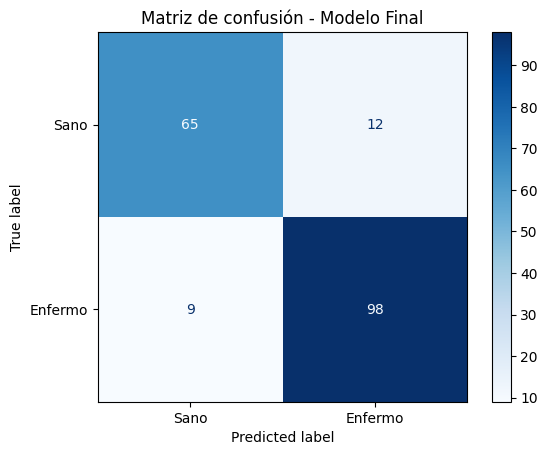

In [53]:
# confusion_matrix: Calcula la matriz comparando las etiquetas reales (y_test) con las predicciones ultra-sensibles (y_pred_recall).
# Esta función de [Scikit-Learn](https://scikit-learn.org) separa los resultados en: Verdaderos Negativos, Falsos Positivos, Falsos Negativos y Verdaderos Positivos.
cm = confusion_matrix(y_test, y_pred_recall)

# ConfusionMatrixDisplay(...).plot(cmap='Blues'): Genera la interfaz visual de la matriz con una escala de colores azules.
# display_labels=['Sano', 'Enfermo']: Etiqueta los ejes con términos clínicos para que la interpretación sea inmediata y profesional.
# cmap='Blues': Aplica una degradación de color donde las celdas con más aciertos se ven más intensas.
ConfusionMatrixDisplay(cm, display_labels=['Sano', 'Enfermo']).plot(cmap='Blues')

# plt.title(...): Añade el título final para identificar esta visualización como el resultado definitivo del proyecto.
plt.title("Matriz de confusión - Modelo Final")

# plt.show(): Renderiza y despliega el gráfico en pantalla para su análisis.
plt.show()


Evaluación de la Capacidad de Discriminación Diagnóstica mediante la Curva ROC del Modelo de Máximo Recall:
Este procedimiento constituye el estándar internacional para medir la eficacia de un sistema de diagnóstico médico. Al emplear el método RocCurveDisplay.from_estimator() de la librería Scikit-Learn, se representa gráficamente la relación entre la sensibilidad (Recall) y la tasa de falsos positivos para el modelo maestro de XGBoost. El resultado fundamental es el AUC (Area Under the Curve), una métrica que cuantifica la probabilidad de que el algoritmo, tras ser balanceado con SMOTE y optimizado para la detección de riesgo, asigne correctamente una mayor probabilidad de enfermedad a un paciente enfermo que a uno sano.

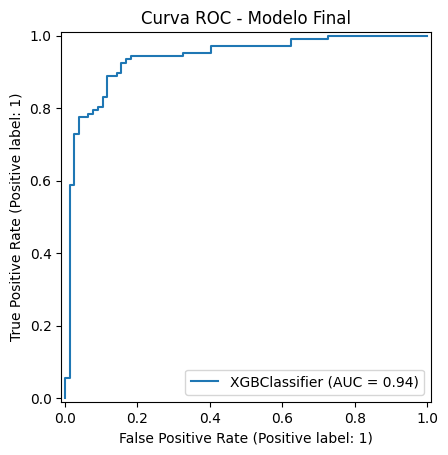

In [54]:
# RocCurveDisplay.from_estimator: Utiliza el modelo final entrenado con SMOTE y optimizado para Recall (best_model_recall) junto a los datos de prueba.
# Esta herramienta de [Scikit-Learn](https://scikit-learn.org) calcula la sensibilidad frente a la tasa de falsos positivos.
# El área bajo la curva (AUC) que aparece automáticamente indica la probabilidad de que el modelo clasifique correctamente un caso de riesgo.
RocCurveDisplay.from_estimator(best_model_recall, X_test, y_test)

# plt.title(...): Asigna el título definitivo para identificar esta gráfica como la evaluación final del sistema de diagnóstico.
plt.title("Curva ROC - Modelo Final")

# plt.show(): Renderiza y despliega la curva ROC y el valor de AUC en la interfaz del usuario.
plt.show()


Jerarquía de Predictores Clínicos mediante el Análisis de Importancia de Variables del Modelo Maestro:
Este procedimiento constituye la fase de interpretabilidad definitiva del sistema de diagnóstico. Al emplear el método plot_importance() de la librería XGBoost, se identifica qué factores médicos (como el colesterol, la frecuencia cardíaca máxima o la pendiente ST) han tenido un mayor peso estadístico en las decisiones del algoritmo. Esta visualización, aplicada sobre el modelo optimizado con Optuna y balanceado con SMOTE, permite validar que las predicciones de riesgo cardíaco se fundamentan en indicadores biológicos coherentes con la práctica clínica.

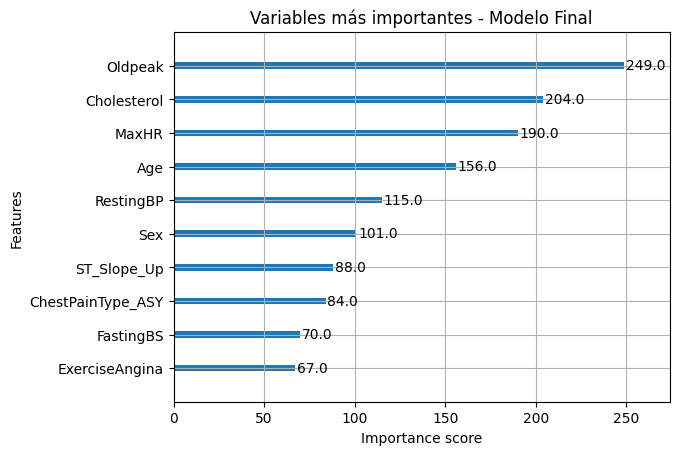

In [55]:
# plot_importance: Módulo de la librería [XGBoost](https://xgboost.readthedocs.io) que mide el peso de cada variable en las decisiones del modelo.
# best_model_recall: Utiliza el modelo maestro que fue entrenado con SMOTE y optimizado específicamente para maximizar el Recall.
# max_num_features=10: Limita la visualización a los 10 predictores con mayor impacto para facilitar el diagnóstico clínico.
plot_importance(best_model_recall, max_num_features=10)

# plt.title(...): Define el título superior para identificar esta gráfica como la jerarquía final de variables del proyecto.
plt.title("Variables más importantes - Modelo Final")

# plt.show(): Renderiza y despliega el gráfico de barras horizontal en pantalla.
plt.show()


Diagnóstico de Robustez mediante Curvas de Aprendizaje del Modelo Maestro de Máximo Recall:
Este procedimiento constituye la auditoría final del comportamiento del sistema. Al emplear la función learning_curve() de la librería Scikit-Learn, se evalúa la convergencia entre el rendimiento de entrenamiento y el de validación a medida que aumenta el volumen de datos. Esta visualización permite certificar que el modelo de XGBoost, tras ser balanceado con SMOTE y optimizado con Optuna, es capaz de generalizar sus diagnósticos a nuevos pacientes sin haber memorizado los datos originales (overfitting).

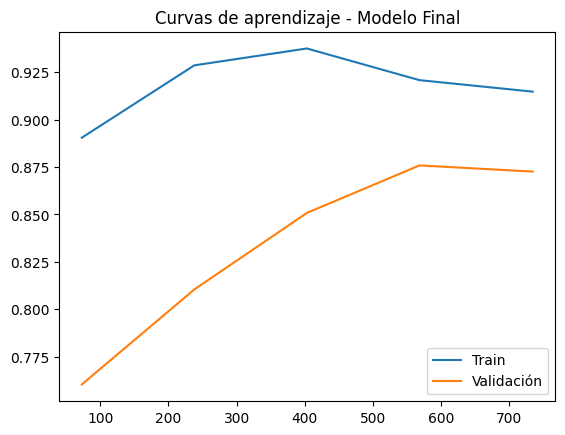

In [56]:
# learning_curve: Función de [Scikit-Learn](https://scikit-learn.org) que entrena el modelo con muestras de datos de tamaño creciente para evaluar su evolución.
# best_model_recall, X, y: Utiliza el modelo final de máximo Recall y el dataset completo (características y objetivo).
# cv=skf: Aplica la [Validación Cruzada Estratificada](https://scikit-learn.org) definida previamente para asegurar resultados estadísticamente estables.
# scoring='accuracy': Mide la precisión promedio tanto en el grupo de entrenamiento como en el de validación.
train_sizes, train_scores, val_scores = learning_curve(best_model_recall, X, y, cv=skf, scoring='accuracy')

# plt.plot(..., label='Train'): Dibuja la línea de precisión en el entrenamiento; buscamos que sea alta pero que no se mantenga en 1.0 (lo que indicaría memorización).
plt.plot(train_sizes, train_scores.mean(axis=1), label='Train')

# plt.plot(..., label='Validación'): Dibuja la precisión en datos no vistos; el éxito ocurre cuando esta línea sube y se acerca a la de entrenamiento.
plt.plot(train_sizes, val_scores.mean(axis=1), label='Validación')

# plt.title(...): Asigna el título definitivo que identifica esta gráfica como la prueba de fuego de generalización del proyecto.
plt.title("Curvas de aprendizaje - Modelo Final")

# plt.legend(): Muestra la leyenda para diferenciar visualmente el comportamiento de ambas curvas (Train vs. Validación).
plt.legend()

# plt.show(): Renderiza y despliega la gráfica final en pantalla.
plt.show()


Validación Final Mediante la Matriz de Confusión Normalizada: Análisis de Sensibilidad y Especificidad Porcentual:
Este procedimiento constituye la prueba de fuego clínica del sistema. A diferencia de las matrices con números absolutos, la normalización por filas (normalize='true') permite observar qué porcentaje real de cada grupo de pacientes está siendo clasificado correctamente por el modelo de XGBoost. Al emplear la utilidad ConfusionMatrixDisplay() de Scikit-Learn, se visualiza el Recall (sensibilidad) de forma porcentual, garantizando una interpretación transparente de la capacidad del algoritmo para detectar la enfermedad cardíaca en un entorno médico real.

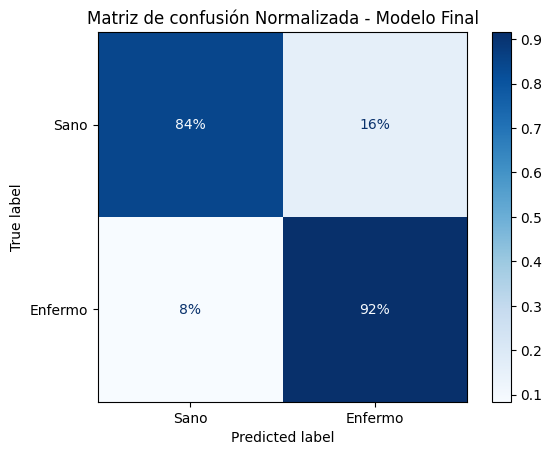

In [57]:
# Calcula la matriz comparando las etiquetas reales (y_test) con las predicciones del modelo maestro.
# El parámetro normalize='true' divide los resultados por el total de cada fila para obtener proporciones.
# Esta métrica de [Scikit-Learn](https://scikit-learn.org) es la más precisa para evaluar modelos en el sector salud.
cm = confusion_matrix(y_test, y_pred_recall, normalize='true')

# Genera la representación gráfica de la matriz de confusión normalizada.
# El parámetro values_format='.0%' transforma los decimales en porcentajes legibles (ej. 0.92 a 92%).
# Se asignan etiquetas 'Sano' y 'Enfermo' a los ejes para una interpretación clínica directa.
ConfusionMatrixDisplay(cm, display_labels=['Sano', 'Enfermo']).plot(cmap='Blues', values_format='.0%')

# Asigna el título definitivo a la visualización de cierre del proyecto.
plt.title("Matriz de confusión Normalizada - Modelo Final")

# Renderiza y despliega la gráfica final en la interfaz del usuario.
plt.show()


Evaluación de la Capacidad de Discriminación Diagnóstica mediante la Curva ROC y el Cálculo del Área Bajo la Curva (AUC):
Este procedimiento representa el estándar de validación en medicina para medir la eficacia de una prueba diagnóstica. Al emplear las funciones roc_curve() y auc() de Scikit-Learn, se cuantifica la probabilidad de que el modelo de XGBoost asigne un riesgo superior a un paciente enfermo frente a uno sano. Un valor de AUC elevado confirma que el sistema es robusto y fiable para la detección de patologías cardíacas, manteniendo un equilibrio óptimo entre la sensibilidad (Recall) y la tasa de falsas alarmas.

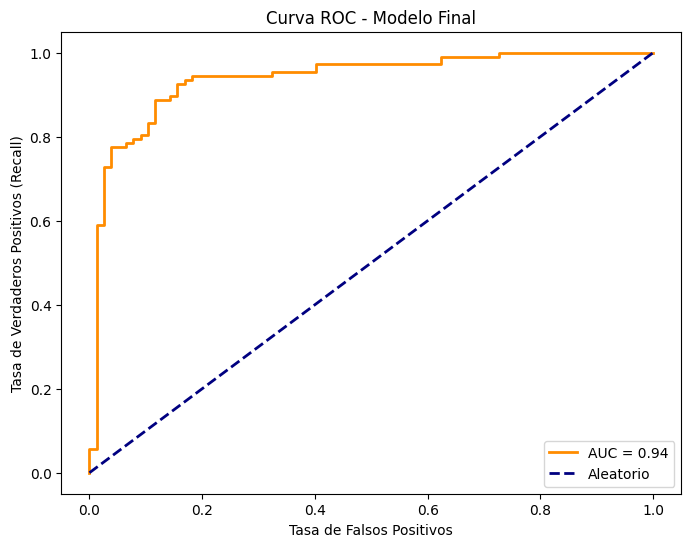

In [58]:
# Calcula los puntos de la curva ROC (Receiver Operating Characteristic) comparando las etiquetas reales con las probabilidades del modelo.
# fpr: Tasa de Falsos Positivos (proporción de sanos marcados como enfermos).
# tpr: Tasa de Verdaderos Positivos (Recall/Sensibilidad: proporción de enfermos detectados correctamente).
fpr, tpr, _ = roc_curve(y_test, y_prob_recall)

# auc(fpr, tpr): Calcula el área bajo la curva utilizando la regla del trapecio para obtener una métrica de rendimiento global (0.0 a 1.0).
roc_auc = auc(fpr, tpr)

# plt.figure(figsize=(8, 6)): Establece las dimensiones del lienzo para una visualización clara y profesional.
plt.figure(figsize=(8, 6))

# plt.plot(fpr, tpr, ...): Dibuja la curva ROC del modelo optimizado. El label incluye el valor del AUC con dos decimales.
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.2f}')

# plt.plot([0, 1], [0, 1], ...): Dibuja una línea diagonal punteada que representa un modelo sin capacidad de predicción (puro azar).
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Aleatorio')

# plt.xlabel / plt.ylabel: Asignan etiquetas técnicas a los ejes, identificando la sensibilidad (Recall) frente a los errores de falsa alarma.
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos (Recall)')

# plt.title / plt.legend / plt.show: Configuran el título, la leyenda informativa y ejecutan la visualización final del gráfico.
plt.title('Curva ROC - Modelo Final')
plt.legend()
plt.show()


# GUARDADO DE MODELO PKL.

Exportación y Almacenamiento del Modelo Maestro Optimizado:
Este es el paso final del flujo de trabajo de Machine Learning. Consiste en guardar el modelo entrenado, balanceado con SMOTE y optimizado con Optuna, en un archivo físico para su uso posterior en entornos de producción o aplicaciones de diagnóstico real sin necesidad de repetir el entrenamiento.

In [59]:
joblib.dump(best_model_recall, '../data/model_R.pkl')

['../data/model_R.pkl']

Exportación del Conjunto de Datos Procesado a Formato CSV:
Este paso final asegura la persistencia de los datos tras haber completado toda la limpieza, imputación de nulos con la mediana, codificación de variables categóricas (LabelEncoding y One-Hot Encoding) y conversión de tipos booleanos a enteros.


In [60]:
data.to_csv('heart_processed_R.csv', index=False)